# ERT inversion resistivity → temperature correction → soil water content (SWC) → cumulative root water uptake (RWU).

In [1]:
"""
main_pipeline.py
================
End-to-end workflow: ERT inversion resistivity → temperature correction
→ soil water content (SWC) → cumulative root water uptake (RWU).

Genotypes analysed
------------------
  WM203   (x = 23–27 m)
  WM140   (x = 17–21 m)
  IPLR760 (x = 11–15 m)

Pipeline overview
-----------------
1.  Load TDR time-series, apply QC, build daily medians.
2.  Interpolate soil temperature to each inversion layer.
3.  Read inversion .dat files, apply temperature correction to resistivity.
4.  Extract ERT resistivity at TDR sensor locations (Global-1 calibration).
5.  Cross-validate a Random-Forest model (ERT rho → theta).
6.  Predict SWC for every genotype / layer / date.
7.  Derive cumulative RWU under the terminal-drought assumption.
8.  Save five publication-quality figures + all intermediate CSV tables.

Quick-start
-----------
1.  Set RAW_DATA_DIR below to your project root's `raw_data/` folder.
2.  Adjust PLOT_START_DATE / PLOT_END_DATE if needed.
3.  Run:  python main_pipeline.py
"""

from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
matplotlib.use("Agg")


# =============================================================================
# CONFIGURATION — edit these constants to adapt the pipeline to new data
# =============================================================================

# Dates on which ERT inversion files exist (one per date, named f001_res.dat …)
INVERSION_DATES = pd.to_datetime([
    "2024-01-13", "2024-01-19",
    "2024-02-07", "2024-02-08", "2024-02-09", "2024-02-10",
    "2024-02-11", "2024-02-12", "2024-02-13", "2024-02-14",
    "2024-02-18", "2024-02-21", "2024-02-22", "2024-02-25",
    "2024-02-26", "2024-02-28", "2024-02-29",
    "2024-03-02", "2024-03-04", "2024-03-06", "2024-03-07",
    "2024-03-09", "2024-03-10", "2024-03-11", "2024-03-14",
    "2024-03-15", "2024-03-16", "2024-03-17", "2024-03-20",
    "2024-03-23", "2024-03-25", "2024-03-27", "2024-03-28",
    "2024-03-30", "2024-03-31",
    "2024-04-03", "2024-04-05", "2024-04-06", "2024-04-08",
    "2024-04-23", "2024-04-24", "2024-04-25", "2024-04-26", "2024-04-27",
])

# Soil layers: each tuple is (y_top, y_bottom) in inversion coordinates
# (negative = below surface). 10 layers of 0.1 m each, 0–1 m depth.
LAYER_BOUNDS_Y: List[Tuple[float, float]] = [
    (-0.1, -0.0), (-0.2, -0.1), (-0.3, -0.2), (-0.4, -0.3), (-0.5, -0.4),
    (-0.6, -0.5), (-0.7, -0.6), (-0.8, -0.7), (-0.9, -0.8), (-1.0, -0.9),
]
LAYER_CENTERS_DEPTH_M = [abs((y0 + y1) / 2.0) for y0, y1 in LAYER_BOUNDS_Y]
LAYER_THICKNESS_M = 0.1

# Canonical display depth for each layer (bottom edge: 0.1, 0.2, …, 1.0 m)
LAYER_DISPLAY_DEPTHS = [round(abs(y0), 1) for y0, y1 in LAYER_BOUNDS_Y]
LAYER_DISPLAY_LABELS = [f"{d:.1f}" for d in LAYER_DISPLAY_DEPTHS]
# Maps internal midpoint depth → human-readable label used on all plot axes
LAYER_CENTER_TO_LABEL = dict(zip(LAYER_CENTERS_DEPTH_M, LAYER_DISPLAY_LABELS))

# Genotype x-ranges in the ERT section (metres along the transect)
GENOTYPE_X_RANGES: Dict[str, Tuple[float, float]] = {
    "WM203":   (23.0, 27.0),
    "WM140":   (17.0, 21.0),
    "IPLR760": (11.0, 15.0),
}
GENO_ORDER   = ["WM203", "WM140", "IPLR760"]   # left-to-right panel order
PANEL_LABELS = ["a.", "b.", "c."]

# Date window shown on all time-series and heatmap figures
PLOT_START_DATE = pd.Timestamp("2024-02-07")
PLOT_END_DATE   = pd.Timestamp("2024-04-15")

# Temperature correction for ERT resistivity
# rho_corr = rho_raw * (1 + ALPHA_PER_C * (T_measured - T_REF_C))
T_REF_C     = 25.0   # reference temperature (°C)
ALPHA_PER_C = 0.02   # correction coefficient per °C

# TDR sensors: position (x_m), depth (depth_m), and datalogger sensor ID
SENSOR_META = pd.DataFrame([
    {"x_m": 15.0, "depth_m": 0.2, "sensor_id": 8501643},
    {"x_m": 15.0, "depth_m": 0.4, "sensor_id": 8501653},
    {"x_m": 15.0, "depth_m": 0.6, "sensor_id": 8501767},
    {"x_m": 15.0, "depth_m": 1.5, "sensor_id": 8501679},
    {"x_m": 23.0, "depth_m": 0.4, "sensor_id": 8501693},
    {"x_m": 23.0, "depth_m": 0.6, "sensor_id": 8501718},
    {"x_m": 23.0, "depth_m": 1.5, "sensor_id": 8501741},
])
SENSOR_META["sensor_id"] = SENSOR_META["sensor_id"].astype(int)
TEMP_DEPTHS = sorted(SENSOR_META["depth_m"].unique().tolist())

# ── Path to raw data ────────────────────────────────────────────────────────
# Update this to the absolute path of your raw_data folder.
RAW_DATA_DIR = Path(
    r"C:\Users\owner\OneDrive - huji.ac.il\שולחן העבודה"
    r"\Wheat field ERT\Inversion_to_RWU_MultiGenotype_Analysis\raw_data"
).resolve()

# ── Figure size constants (inches at 600 DPI) ───────────────────────────────
FIG_SINGLE   = (12.0, 7.0)    # single-panel wide figure
FIG_1X3_WIDE = (20.0, 8.0)    # three-panel, full page width
FIG_1X3_TALL = (20.0, 9.0)    # three-panel with more vertical room
FIG_DPI      = 600


# =============================================================================
# PATHS
# =============================================================================

@dataclass
class Paths:
    root:              Path
    raw_inversion_dir: Path
    raw_tdr_dir:       Path
    metadata_dir:      Path
    figures_dir:       Path
    report_dir:        Path
    tables_dir:        Path


def resolve_paths() -> Paths:
    root = RAW_DATA_DIR.parent
    return Paths(
        root              = root,
        raw_inversion_dir = RAW_DATA_DIR / "inversion_res_dat",
        raw_tdr_dir       = RAW_DATA_DIR / "tdr_exports",
        metadata_dir      = RAW_DATA_DIR / "metadata",
        figures_dir       = root / "figures",
        report_dir        = root / "report",
        tables_dir        = root / "report" / "tables",
    )


# =============================================================================
# UTILITIES
# =============================================================================

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def rolling_median(y: np.ndarray, win: int = 3) -> np.ndarray:
    """Center-aligned rolling median with min_periods=1 to avoid edge NaNs."""
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=int(win), center=True, min_periods=1).median().to_numpy(dtype=float)


def _save_fig(fig: plt.Figure, out_file: Path) -> None:
    """Save figure at FIG_DPI with tight bounding box, then close."""
    fig.savefig(out_file, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)


# =============================================================================
# STEP 1 — TDR DATA LOADING AND QC
# =============================================================================

def load_tdr_data(raw_tdr_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load all TDR CSV exports from raw_tdr_dir.

    Returns
    -------
    tdr_qc    : quality-controlled sub-hourly time-series
    tdr_daily : daily medians per sensor (theta, temp, bulk resistivity)
    """
    if not raw_tdr_dir.exists():
        raise FileNotFoundError(f"TDR folder not found: {raw_tdr_dir}")

    # Collect files (try DataSnap pattern first, then any CSV)
    files: List[Path] = []
    for pattern in ["DataSnapExport_*.csv", "*.csv", "*.CSV"]:
        files.extend(sorted(raw_tdr_dir.glob(pattern)))
    files = list(dict.fromkeys(files))  # deduplicate while preserving order

    if not files:
        raise FileNotFoundError(f"No CSV files in {raw_tdr_dir}")

    required_cols = {"Time", "SensorId", "Reading1", "Reading2"}
    all_cols      = required_cols | {"Reading3", "Reading4"}
    frames: List[pd.DataFrame] = []

    for f in files:
        try:
            df = pd.read_csv(f, usecols=lambda c: c in all_cols,
                             low_memory=False, encoding_errors="ignore")
        except Exception:
            continue
        if not required_cols.issubset(df.columns):
            continue
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No readable TDR exports in {raw_tdr_dir}")

    tdr = pd.concat(frames, ignore_index=True)

    # Parse timestamps and sensor IDs
    tdr["timestamp"] = pd.to_datetime(tdr["Time"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    tdr = tdr.dropna(subset=["timestamp", "SensorId"]).copy()
    tdr["sensor_id"] = pd.to_numeric(tdr["SensorId"], errors="coerce").astype("Int64")
    tdr = tdr.dropna(subset=["sensor_id"]).copy()
    tdr["sensor_id"] = tdr["sensor_id"].astype(int)

    for col in ["Reading1", "Reading2", "Reading3", "Reading4"]:
        if col in tdr.columns:
            tdr[col] = pd.to_numeric(tdr[col], errors="coerce")

    # Keep only sensors we know about
    tdr = tdr[tdr["sensor_id"].isin(SENSOR_META["sensor_id"])].copy()

    # Merge overlapping exports: average readings at the same timestamp+sensor
    tdr = (tdr.groupby(["timestamp", "sensor_id"], as_index=False)
              .mean(numeric_only=True)
              .sort_values("timestamp"))
    tdr = tdr.merge(SENSOR_META, on="sensor_id", how="left")

    # Physical readings:
    #   Reading1 = VWC (%)  → theta_tdr (m³/m³)
    #   Reading2 = soil temperature (°C)
    #   Reading3 or Reading4 = bulk electrical resistivity (if available)
    tdr["theta_tdr"] = tdr["Reading1"] / 100.0
    tdr["temp_c"]    = tdr["Reading2"]
    tdr["bulk_rho_tdr"] = np.nan
    if "Reading3" in tdr.columns and tdr["Reading3"].notna().any():
        tdr["bulk_rho_tdr"] = tdr["Reading3"]
    elif "Reading4" in tdr.columns and tdr["Reading4"].notna().any():
        tdr["bulk_rho_tdr"] = tdr["Reading4"]

    # QC filters
    tdr_qc = tdr[
        tdr["theta_tdr"].between(0.0, 0.70, inclusive="both") &
        tdr["temp_c"].between(0.0, 50.0, inclusive="both")
    ].copy()
    tdr_qc["date"] = tdr_qc["timestamp"].dt.floor("D")

    # Daily aggregation per sensor
    tdr_daily = (
        tdr_qc.groupby(["date", "sensor_id", "x_m", "depth_m"], as_index=False)
        .agg(
            theta_tdr    = ("theta_tdr",    "median"),
            temp_c       = ("temp_c",       "median"),
            bulk_rho_tdr = ("bulk_rho_tdr", "median"),
            n_obs        = ("theta_tdr",    "size"),
        )
        .sort_values(["date", "sensor_id"])
        .reset_index(drop=True)
    )

    return tdr_qc, tdr_daily


# =============================================================================
# STEP 2 — TEMPERATURE INTERPOLATION TO INVERSION LAYERS
# =============================================================================

def build_depth_daily_temperature(tdr_qc: pd.DataFrame) -> pd.DataFrame:
    """
    Compute daily mean temperature at each instrumented depth.

    Missing days are filled by linear time-interpolation so that every
    inversion date has a complete temperature profile.
    """
    # Pivot to (date × sensor_id) matrix of daily median temperatures
    daily_sensor = (
        tdr_qc.groupby(["date", "sensor_id"], as_index=False)["temp_c"]
        .median()
        .pivot(index="date", columns="sensor_id", values="temp_c")
        .sort_index()
    )

    # Fill the full date range and interpolate gaps
    full_idx    = pd.date_range(INVERSION_DATES.min(), INVERSION_DATES.max(), freq="D")
    daily_interp = daily_sensor.reindex(full_idx).interpolate(method="time", limit_direction="both")

    rows = []
    for depth in TEMP_DEPTHS:
        sids = SENSOR_META.loc[np.isclose(SENSOR_META["depth_m"], depth), "sensor_id"].tolist()
        if not sids:
            continue
        slice_   = daily_interp[sids]
        mean_col = slice_.mean(axis=1)
        sd_col   = slice_.std(axis=1, ddof=0).fillna(0.0)
        for dt, tm, tsd in zip(mean_col.index, mean_col.to_numpy(), sd_col.to_numpy()):
            rows.append({"date": pd.Timestamp(dt), "depth_m": float(depth),
                         "temp_mean_c": float(tm), "temp_sd_c": float(tsd)})

    return pd.DataFrame(rows).sort_values(["date", "depth_m"]).reset_index(drop=True)


def interpolate_temperature_to_layers(depth_daily_temp: pd.DataFrame) -> pd.DataFrame:
    """
    Vertically interpolate daily temperature to the midpoint of each
    inversion layer (LAYER_CENTERS_DEPTH_M).

    Only dates matching INVERSION_DATES are retained in the output.
    """
    rows = []
    for date, g in depth_daily_temp.groupby("date"):
        g = g.sort_values("depth_m")
        depth_vals = g["depth_m"].to_numpy(dtype=float)
        temp_vals  = g["temp_mean_c"].to_numpy(dtype=float)

        # np.interp extrapolates by clamping at boundary values
        t_layer = np.interp(
            np.asarray(LAYER_CENTERS_DEPTH_M, dtype=float),
            depth_vals, temp_vals,
            left=temp_vals[0], right=temp_vals[-1],
        )
        for i, (d, t) in enumerate(zip(LAYER_CENTERS_DEPTH_M, t_layer), start=1):
            rows.append({"date": pd.Timestamp(date), "layer": int(i),
                         "depth_m": float(d), "temp_interp_c": float(t)})

    out = pd.DataFrame(rows)
    out = out[out["date"].isin(INVERSION_DATES)].copy()
    return out.sort_values(["date", "layer"]).reset_index(drop=True)


# =============================================================================
# STEP 3 — INVERSION FILE PARSING AND TEMPERATURE CORRECTION
# =============================================================================

def read_inversion_res_file(file_path: Path) -> pd.DataFrame:
    """Parse a whitespace-delimited inversion result file (x, y, rho, log_rho)."""
    return pd.read_csv(file_path, sep=r"\s+", header=None,
                       names=["x", "y", "rho_raw", "log_rho"])


def extract_corrected_profiles(paths: Paths, layer_temp: pd.DataFrame) -> pd.DataFrame:
    """
    For each inversion date, extract resistivity per genotype zone and layer,
    apply the linear temperature correction, and return summary statistics.

    Correction formula:
        rho_corr = rho_raw * (1 + ALPHA_PER_C * (T - T_REF_C))

    Returns a DataFrame with median, P25, and P75 corrected resistivity
    for every (genotype, date, layer) combination.
    """
    tlookup = layer_temp.set_index(["date", "layer"])
    rows = []

    for idx, date in enumerate(INVERSION_DATES, start=1):
        f = paths.raw_inversion_dir / f"f{idx:03d}_res.dat"
        if not f.exists():
            continue
        d = read_inversion_res_file(f)

        for genotype, (x_min, x_max) in GENOTYPE_X_RANGES.items():
            d_gen = d[(d["x"] >= x_min) & (d["x"] <= x_max)].copy()

            for layer_idx, (y_min, y_max) in enumerate(LAYER_BOUNDS_Y, start=1):
                sub = d_gen[(d_gen["y"] >= y_min) & (d_gen["y"] <= y_max)].copy()
                if sub.empty:
                    continue
                if (pd.Timestamp(date), layer_idx) not in tlookup.index:
                    continue

                temp_c   = float(tlookup.loc[(pd.Timestamp(date), layer_idx)]["temp_interp_c"])
                cf       = 1.0 + ALPHA_PER_C * (temp_c - T_REF_C)
                rho_corr = sub["rho_raw"].to_numpy(dtype=float) * cf

                rows.append({
                    "genotype":        genotype,
                    "date":            pd.Timestamp(date),
                    "layer":           int(layer_idx),
                    "depth_m":         float(LAYER_CENTERS_DEPTH_M[layer_idx - 1]),
                    "rho_corr_median": float(np.median(rho_corr)),
                    "rho_corr_p25":    float(np.percentile(rho_corr, 25)),
                    "rho_corr_p75":    float(np.percentile(rho_corr, 75)),
                    "rho_corr_n":      int(len(rho_corr)),
                })

    return pd.DataFrame(rows).sort_values(["genotype", "date", "layer"]).reset_index(drop=True)


# =============================================================================
# STEP 4 — ERT AT TDR SENSOR LOCATIONS (calibration dataset)
# =============================================================================

def extract_ert_at_tdr_sensors(paths: Paths, tdr_daily: pd.DataFrame) -> pd.DataFrame:
    """
    For each inversion date, look up the ERT resistivity at every TDR sensor
    location using the nearest k ≤ 20 inversion cells within a ±0.45 m (x)
    and ±0.20 m (y) window. Pairs with TDR daily medians and applies
    temperature correction using the sensor's own measured temperature.

    This paired dataset is used to train and validate the ERT→theta model.
    """
    rows = []
    for i, date in enumerate(INVERSION_DATES, start=1):
        f = paths.raw_inversion_dir / f"f{i:03d}_res.dat"
        if not f.exists():
            continue
        d = read_inversion_res_file(f)

        for _, srow in SENSOR_META.iterrows():
            x0 = float(srow["x_m"])
            z0 = float(srow["depth_m"])
            y0 = -z0                   # inversion y-coordinate (negative = depth)
            sid = int(srow["sensor_id"])

            # Window search; fall back to entire transect if window is empty
            local = d[(np.abs(d["x"] - x0) <= 0.45) & (np.abs(d["y"] - y0) <= 0.20)].copy()
            if local.empty:
                local = d.copy()

            local["dist"] = np.sqrt((local["x"] - x0)**2 + (local["y"] - y0)**2)
            k = max(1, min(20, len(local)))
            rho_local = float(local.nsmallest(k, "dist")["rho_raw"].median())

            rows.append({"date": pd.Timestamp(date), "sensor_id": sid,
                         "x_m": x0, "depth_m": z0, "rho_raw_local_median": rho_local})

    ert    = pd.DataFrame(rows)
    merged = tdr_daily.merge(ert, on=["date", "sensor_id", "x_m", "depth_m"], how="inner")
    merged["rho_corr_local"] = merged["rho_raw_local_median"] * (
        1.0 + ALPHA_PER_C * (merged["temp_c"] - T_REF_C)
    )

    # Filter physically implausible values
    merged = merged[
        merged["theta_tdr"].between(0.01, 0.70) &
        np.isfinite(merged["rho_corr_local"]) &
        (merged["rho_corr_local"] > 0.01)
    ].copy()

    return merged.sort_values(["date", "sensor_id"]).reset_index(drop=True)


# =============================================================================
# STEP 5 — RANDOM FOREST ERT→THETA MODEL
# =============================================================================

class RFDepthModel:
    """
    Random Forest regressor that predicts volumetric water content (theta,
    m³/m³) from ERT resistivity and soil depth.

    Features:  [ln(rho_corr),  depth_m]
    Target:    theta_tdr (m³/m³)

    Using log-resistivity linearises the Archie-like relationship and makes
    the model more robust across the resistivity range observed in the field.
    """
    name = "random_forest_depth"

    def __init__(self) -> None:
        self.model = RandomForestRegressor(
            n_estimators=600, random_state=42,
            min_samples_leaf=3, n_jobs=-1,
        )

    @staticmethod
    def _build_features(df: pd.DataFrame, rho_col: str) -> np.ndarray:
        return np.column_stack([
            np.log(np.clip(df[rho_col].to_numpy(dtype=float), 1e-8, None)),
            df["depth_m"].to_numpy(dtype=float),
        ])

    def fit(self, train_df: pd.DataFrame, rho_col: str) -> None:
        x = self._build_features(train_df, rho_col)
        y = train_df["theta_tdr"].to_numpy(dtype=float)
        self.model.fit(x, y)

    def predict(self, df: pd.DataFrame, rho_col: str) -> np.ndarray:
        pred = self.model.predict(self._build_features(df, rho_col))
        return np.clip(pred, 0.0, 0.7)


def cross_validate_rf(
    df: pd.DataFrame,
    rho_col: str,
) -> Tuple[pd.DataFrame, pd.DataFrame, RFDepthModel]:
    """
    GroupKFold cross-validation of RFDepthModel, grouped by date so that
    the same date never appears in both train and test sets.

    Returns
    -------
    metrics     : one-row DataFrame with RMSE, MAE, R², bias
    oof         : input df extended with out-of-fold predictions
    final_model : model re-fitted on all data
    """
    if df.empty:
        return pd.DataFrame(), pd.DataFrame(), RFDepthModel()

    n_splits = max(2, min(5, df["date"].nunique()))
    gkf      = GroupKFold(n_splits=n_splits)
    groups   = df["date"].astype(str).to_numpy()
    y_true   = df["theta_tdr"].to_numpy(dtype=float)
    oof_pred = np.full(len(df), np.nan, dtype=float)

    for tr, te in gkf.split(df, y_true, groups):
        m = RFDepthModel()
        m.fit(df.iloc[tr].copy(), rho_col=rho_col)
        oof_pred[te] = m.predict(df.iloc[te].copy(), rho_col=rho_col)

    ok = np.isfinite(oof_pred)
    if ok.sum() < max(20, int(0.6 * len(df))):
        return pd.DataFrame(), pd.DataFrame(), RFDepthModel()

    yt, yp = y_true[ok], oof_pred[ok]
    metrics = pd.DataFrame([{
        "model":     RFDepthModel.name,
        "rho_col":   rho_col,
        "n_obs":     int(ok.sum()),
        "rmse":      rmse(yt, yp),
        "mae":       float(mean_absolute_error(yt, yp)),
        "r2":        float(r2_score(yt, yp)),
        "bias_mean": float(np.mean(yp - yt)),
        "n_splits":  int(n_splits),
    }])

    oof = df.copy()
    oof["theta_pred_cv"] = oof_pred

    final_model = RFDepthModel()
    final_model.fit(df, rho_col=rho_col)
    return metrics, oof, final_model


# =============================================================================
# STEP 6 — SWC CONVERSION
# =============================================================================

def convert_profiles_to_swc(
    profile_summary: pd.DataFrame,
    model: RFDepthModel,
    rho_col: str,
) -> pd.DataFrame:
    """
    Apply the trained ERT→theta model to all (genotype, date, layer) rows in
    profile_summary.  Predictions are made for the median, P25, and P75
    resistivity values to propagate spatial uncertainty into the SWC estimate.
    """
    conv = profile_summary.copy()

    def _predict_col(src_col: str) -> np.ndarray:
        tmp = pd.DataFrame({
            "depth_m":  conv["depth_m"].to_numpy(dtype=float),
            "theta_tdr": np.zeros(len(conv), dtype=float),  # unused placeholder
        })
        tmp[rho_col] = np.clip(conv[src_col].to_numpy(dtype=float), 1e-8, None)
        return model.predict(tmp, rho_col=rho_col)

    theta_med = _predict_col("rho_corr_median")
    theta_p25 = _predict_col("rho_corr_p25")
    theta_p75 = _predict_col("rho_corr_p75")

    conv["theta_pred_median"] = theta_med
    conv["theta_pred_low"]    = np.minimum(theta_p25, theta_p75)
    conv["theta_pred_high"]   = np.maximum(theta_p25, theta_p75)

    return conv.sort_values(["genotype", "date", "layer"]).reset_index(drop=True)


# =============================================================================
# STEP 7 — ROOT WATER UPTAKE COMPUTATION
# =============================================================================

def _rwu_from_theta(theta: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute cumulative root water uptake from a theta time-series using the
    terminal-drought (monotonic drying) assumption:

        theta_mono(t) = min_{tau <= t} theta(tau)     # enforce monotonic decline
        RWU_step(t)   = max(0, -Δtheta_mono(t)) * dz * 1000   [mm]
        RWU_cum(t)    = cumsum(RWU_step)

    Parameters
    ----------
    theta : 1-D array of theta values ordered in time

    Returns
    -------
    t_mono   : monotonically non-increasing theta
    step_mm  : water extracted at each time step (mm)
    cum_mm   : cumulative extraction (mm)
    """
    t       = np.asarray(theta, dtype=float)
    t_mono  = np.minimum.accumulate(t)
    dtheta  = -(np.diff(t_mono, prepend=t_mono[0]))
    step_mm = np.clip(dtheta, 0.0, None) * LAYER_THICKNESS_M * 1000.0
    cum_mm  = np.cumsum(step_mm)
    return t_mono, step_mm, cum_mm


def compute_rwu(conv: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute per-layer and total cumulative RWU for all genotypes.

    The uncertainty bounds (low/high) are derived by running _rwu_from_theta
    on the P25 and P75 SWC scenarios and taking element-wise min/max.

    Returns
    -------
    rwu       : per-layer time-series with step and cumulative RWU
    total_rwu : total (summed over depth) cumulative RWU per genotype per date
    """
    rows: List[pd.DataFrame] = []

    for (genotype, layer), g in conv.groupby(["genotype", "layer"], sort=True):
        gg = g.sort_values("date").copy()

        t_med, step_med, cum_med = _rwu_from_theta(gg["theta_pred_median"].to_numpy(dtype=float))
        _, step_wet, cum_wet     = _rwu_from_theta(gg["theta_pred_high"].to_numpy(dtype=float))
        _, step_dry, cum_dry     = _rwu_from_theta(gg["theta_pred_low"].to_numpy(dtype=float))

        cum_stack  = np.column_stack([cum_med,  cum_wet,  cum_dry])
        step_stack = np.column_stack([step_med, step_wet, step_dry])

        out = gg.copy()
        out["theta_med_mono"]   = t_med
        out["rwu_step_med_mm"]  = step_med
        out["rwu_step_low_mm"]  = np.nanmin(step_stack, axis=1)
        out["rwu_step_high_mm"] = np.nanmax(step_stack, axis=1)
        out["rwu_cum_med_mm"]   = cum_med
        out["rwu_cum_low_mm"]   = np.nanmin(cum_stack, axis=1)
        out["rwu_cum_high_mm"]  = np.nanmax(cum_stack, axis=1)
        rows.append(out)

    rwu = (pd.concat(rows, ignore_index=True)
             .sort_values(["genotype", "date", "layer"])
             .reset_index(drop=True))

    total_rwu = (
        rwu.groupby(["genotype", "date"], as_index=False)
        .agg(rwu_total_cum_med_mm=("rwu_cum_med_mm", "sum"))
        .sort_values(["genotype", "date"])
        .reset_index(drop=True)
    )
    return rwu, total_rwu


# =============================================================================
# STEP 8 — FIGURES
# =============================================================================

def fig01_total_rwu_timeseries(
    total_rwu: pd.DataFrame, out_file: Path, smooth_win: int = 3
) -> None:
    """
    Figure 1: Cumulative total root water uptake (summed over all layers)
    for each genotype, plotted against calendar date.
    """
    g0 = total_rwu.copy()
    g0["date"] = pd.to_datetime(g0["date"])
    t0 = pd.Timestamp(INVERSION_DATES.min())
    g0["day"] = (g0["date"] - t0).dt.days.to_numpy()
    start_day = int((PLOT_START_DATE - t0).days)
    end_day   = int((PLOT_END_DATE   - t0).days)

    fig, ax = plt.subplots(figsize=FIG_SINGLE)

    for geno in GENO_ORDER:
        gg = g0[g0["genotype"] == geno].sort_values("day")
        if gg.empty:
            continue
        days  = gg["day"].to_numpy()
        dates = gg["date"].to_numpy()
        y     = rolling_median(gg["rwu_total_cum_med_mm"].to_numpy(dtype=float), win=smooth_win)
        mask  = (days >= start_day) & (days <= end_day)
        ax.plot(dates[mask], y[mask], marker="o", ms=5, lw=1.8, label=geno)

    ax.set_xlim(PLOT_START_DATE, PLOT_END_DATE)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    fig.autofmt_xdate(rotation=35, ha="right")

    ax.set_title("Cumulative Root Water Uptake", pad=12, fontsize=18)
    ax.set_xlabel("Date", labelpad=8, fontsize=18)
    ax.set_ylabel("Root Water Uptake (mm)", labelpad=8, fontsize=18)
    ax.tick_params(axis="both", labelsize=18)
    ax.set_ylim(0.0, max(5.0, float(np.nanmax(g0["rwu_total_cum_med_mm"])) * 1.05))
    ax.grid(True, alpha=0.4)
    ax.legend(loc="upper left", fontsize=18)
    fig.tight_layout(pad=2.0)
    _save_fig(fig, out_file)


def fig02_rwu_heatmaps(
    rwu: pd.DataFrame, out_file: Path, smooth_sigma: float = 0.9
) -> None:
    """
    Figure 2: Three-panel (1 × 3) heatmap of cumulative RWU by depth and date
    for each genotype.  Sparse measurement dates are filled by linear
    interpolation before Gaussian smoothing.
    """
    df = rwu.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df[(df["date"] >= PLOT_START_DATE) & (df["date"] <= PLOT_END_DATE)].copy()

    depth_levels = np.sort(df["depth_m"].unique())
    n_depths     = len(depth_levels)
    vmax = float(np.nanmax(df["rwu_cum_med_mm"].to_numpy(dtype=float))) if not df.empty else 1.0
    start_num = mdates.date2num(PLOT_START_DATE.to_pydatetime())
    end_num   = mdates.date2num(PLOT_END_DATE.to_pydatetime())

    fig, axes = plt.subplots(1, 3, figsize=FIG_1X3_TALL, sharex=True, sharey=True)
    fig.subplots_adjust(top=0.88, bottom=0.22, left=0.07, right=0.97, wspace=0.08)
    im_last = None

    for i, geno in enumerate(GENO_ORDER):
        ax = axes[i]
        g  = df[df["genotype"] == geno]
        if g.empty:
            ax.set_axis_off()
            continue

        # Build a pivot table on dates and fill to daily resolution
        pivot = (
            g.pivot_table(index="depth_m", columns="date",
                          values="rwu_cum_med_mm", aggfunc="median")
            .reindex(index=depth_levels)
        )
        full_dates = pd.date_range(PLOT_START_DATE, PLOT_END_DATE, freq="D")
        pivot = pivot.reindex(columns=full_dates)
        z = pivot.to_numpy(dtype=float)

        if smooth_sigma > 0:
            # Linearly fill NaN gaps before Gaussian smoothing
            for row_i in range(z.shape[0]):
                row   = z[row_i]
                valid = np.isfinite(row)
                if valid.sum() > 1:
                    xi = np.where(valid)[0]
                    fi = interp1d(xi, row[valid], bounds_error=False,
                                  fill_value=(row[valid][0], row[valid][-1]))
                    z[row_i] = fi(np.arange(len(row)))
            z = gaussian_filter(z, sigma=float(smooth_sigma), mode="nearest")

        im_last = ax.imshow(
            z, aspect="auto", origin="upper", vmin=0.0, vmax=vmax, cmap="viridis",
            extent=[start_num, end_num, n_depths - 0.5, -0.5],
        )
        ax.xaxis_date()
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=18)

        ax.set_yticks(np.arange(n_depths))
        ax.set_yticklabels(
            [LAYER_CENTER_TO_LABEL.get(d, f"{d:.2f}") for d in depth_levels], fontsize=18
        )
        ax.set_title(geno, fontsize=18, pad=10)
        ax.text(0.01, 1.06, PANEL_LABELS[i], transform=ax.transAxes,
                fontsize=18, va="bottom", fontweight="bold")
        ax.set_ylabel("Depth (m)", fontsize=18)
        ax.set_xlabel("Date", fontsize=18)

    cax = fig.add_axes([0.18, 0.04, 0.64, 0.032])
    cb  = fig.colorbar(im_last, cax=cax, orientation="horizontal")
    cb.set_label("Root Water Uptake (mm)", fontsize=18)
    cb.ax.tick_params(labelsize=14)
    _save_fig(fig, out_file)


def fig03_uptake_proportion_bars(
    rwu: pd.DataFrame, dates: List[str], out_file: Path
) -> None:
    """
    Figure 3: Grouped bar charts showing what fraction of total cumulative
    RWU came from each depth layer at three selected dates.
    The y-axis ceiling is set automatically to the global maximum across
    all genotypes and dates so panels are directly comparable.
    """
    df = rwu.copy()
    df["date"] = pd.to_datetime(df["date"])
    sel_dates  = pd.to_datetime(dates)
    df = df[df["date"].isin(sel_dates)].copy()
    if df.empty:
        return

    depths = np.sort(df["depth_m"].unique())
    x = np.arange(len(depths))

    # Compute global y maximum for a consistent shared axis
    global_pct_max = 0.0
    for geno in GENO_ORDER:
        for dt in sel_dates:
            gg = df[(df["genotype"] == geno) & (df["date"] == dt)]
            if gg.empty:
                continue
            by_d  = gg.groupby("depth_m", as_index=False)["rwu_cum_med_mm"].sum()
            by_d  = by_d.set_index("depth_m").reindex(depths).fillna(0.0)
            total = float(by_d["rwu_cum_med_mm"].sum())
            if total > 0:
                pct = 100.0 * by_d["rwu_cum_med_mm"].to_numpy() / total
                global_pct_max = max(global_pct_max, float(np.nanmax(pct)))

    y_ceil = max(30.0, global_pct_max * 1.12)

    fig, axes = plt.subplots(1, 3, figsize=FIG_1X3_WIDE, sharex=True, sharey=True,
                              constrained_layout=True)

    for i, geno in enumerate(GENO_ORDER):
        ax = axes[i]
        g  = df[df["genotype"] == geno]
        if g.empty:
            ax.set_axis_off()
            continue

        width   = 0.22 if len(sel_dates) <= 3 else 0.16
        offsets = (np.arange(len(sel_dates)) - (len(sel_dates) - 1) / 2.0) * width

        for j, dt in enumerate(sel_dates):
            gg = g[g["date"] == dt].copy()
            if gg.empty:
                continue
            by_d  = gg.groupby("depth_m", as_index=False)["rwu_cum_med_mm"].sum()
            by_d  = by_d.set_index("depth_m").reindex(depths).fillna(0.0)
            total = float(by_d["rwu_cum_med_mm"].sum())
            pct   = (100.0 * by_d["rwu_cum_med_mm"].to_numpy() / total
                     if total > 0 else np.zeros_like(x, dtype=float))

            bars = ax.bar(x + offsets[j], pct, width=width,
                          label=str(pd.Timestamp(dt).date()))
            for b in bars:
                h = b.get_height()
                ax.text(b.get_x() + b.get_width() / 2, h + 0.3,
                        f"{h:.0f}", ha="center", va="bottom", fontsize=10)

        ax.set_title(geno, fontsize=18, pad=10)
        ax.text(0.01, 1.06, PANEL_LABELS[i], transform=ax.transAxes,
                fontsize=18, va="bottom", fontweight="bold")
        ax.set_ylabel("Proportion of Total Uptake (%)", fontsize=18)
        ax.set_xlabel("Depth (m)", fontsize=18)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [LAYER_CENTER_TO_LABEL.get(d, f"{d:.2f}") for d in depths], fontsize=18
        )
        ax.tick_params(axis="y", labelsize=14)
        ax.set_ylim(0.0, y_ceil)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(title="Date", fontsize=18, title_fontsize=18, loc="upper right")

    _save_fig(fig, out_file)


def fig04_depth_profiles(
    rwu: pd.DataFrame, dates: List[str], out_file: Path
) -> None:
    """
    Figure 4: One panel per selected date showing cumulative RWU vs depth
    for all three genotypes, displayed as scatter dots (one dot per layer).
    Each genotype uses a distinct marker shape in addition to colour so
    the figure is legible in greyscale.
    """
    df = rwu.copy()
    df["date"] = pd.to_datetime(df["date"])
    sel_dates  = [pd.Timestamp(d) for d in pd.to_datetime(dates)]
    depths     = np.sort(df["depth_m"].unique())

    global_max = 1.0
    for dt in sel_dates:
        dd = df[df["date"] == dt]
        if not dd.empty:
            global_max = max(global_max, float(np.nanmax(dd["rwu_cum_med_mm"])))
    x_max = global_max * 1.15

    fig, axes = plt.subplots(1, len(sel_dates),
                              figsize=(6.5 * len(sel_dates), 9.0), sharey=True)
    if len(sel_dates) == 1:
        axes = [axes]

    colors      = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    geno_colors = {g: colors[k % len(colors)] for k, g in enumerate(GENO_ORDER)}
    geno_markers = {"IPLR760": ("*", 220), "WM140": ("o", 130), "WM203": ("P", 150)}

    for ax, dt in zip(axes, sel_dates):
        dd = df[df["date"] == dt]
        ax.set_title(f"{dt.strftime('%b %d, %Y')}", fontsize=18, pad=10)

        for geno in ["IPLR760", "WM140", "WM203"]:
            g = dd[dd["genotype"] == geno]
            if g.empty:
                continue
            prof = (g.groupby("depth_m", as_index=False)
                     .agg(med=("rwu_cum_med_mm", "sum"))
                     .set_index("depth_m")
                     .reindex(depths))
            vals   = prof["med"].to_numpy(dtype=float)
            valid  = np.isfinite(vals)
            marker, ms = geno_markers[geno]
            ax.scatter(vals[valid], depths[valid], s=ms, zorder=5,
                       color=geno_colors[geno], marker=marker,
                       edgecolors="white", linewidths=0.8, label=geno)

        ax.invert_yaxis()
        ax.set_ylim(depths.max() + 0.05, depths.min() - 0.05)
        ax.set_yticks(depths)
        ax.set_yticklabels(
            [LAYER_CENTER_TO_LABEL.get(d, f"{d:.2f}") for d in depths], fontsize=18
        )
        ax.set_xlim(0.0, x_max)
        ax.xaxis.set_label_position("top")
        ax.xaxis.tick_top()
        ax.set_xlabel("Cumulative RWU (mm)", labelpad=8, fontsize=18)
        ax.set_ylabel("Depth (m)", fontsize=18)
        ax.tick_params(axis="x", labelsize=14)
        ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.grid(True, alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12, linestyle=":")

    axes[-1].legend(loc="lower right", fontsize=18, framealpha=0.85)
    fig.tight_layout(pad=2.5)
    _save_fig(fig, out_file)


def fig05_depth_correlation_heatmaps(
    conv: pd.DataFrame, out_file: Path,
    value_col: str = "theta_pred_median"
) -> None:
    """
    Figure 5: Pearson correlation matrix of predicted SWC between depth layers
    for each genotype.  Only upper-triangle values are shown (the lower
    triangle is masked to avoid visual clutter).
    """
    df = conv.copy()
    df["date"] = pd.to_datetime(df["date"])
    depths = np.sort(df["depth_m"].unique())
    n      = len(depths)
    mask   = np.tril(np.ones((n, n), dtype=bool), k=0)  # mask lower triangle

    fig, axes = plt.subplots(1, 3, figsize=FIG_1X3_WIDE, sharex=True, sharey=True)
    fig.subplots_adjust(top=0.88, bottom=0.22, left=0.07, right=0.97, wspace=0.12)
    im_last = None

    for i, geno in enumerate(GENO_ORDER):
        ax = axes[i]
        g  = df[df["genotype"] == geno]
        if g.empty:
            ax.set_axis_off()
            continue

        p = g.pivot(index="date", columns="depth_m", values=value_col).reindex(columns=depths)
        c = p.corr(method="pearson").to_numpy(dtype=float)
        cmask = np.ma.array(c, mask=mask)

        im_last = ax.imshow(cmask, vmin=0.3, vmax=1.0, cmap="coolwarm", origin="upper")

        ax.set_title(geno, fontsize=18, pad=10)
        ax.text(0.01, 1.06, PANEL_LABELS[i], transform=ax.transAxes,
                fontsize=18, va="bottom", fontweight="bold")
        tick_labels = [LAYER_CENTER_TO_LABEL.get(d, f"{d:.2f}") for d in depths]
        ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
        ax.set_xticklabels(tick_labels, fontsize=18)
        ax.set_yticklabels(tick_labels, fontsize=18)
        ax.set_xlabel("Depth (m)", fontsize=18)
        ax.set_ylabel("Depth (m)", fontsize=18)

        for r in range(n):
            for c_idx in range(n):
                if mask[r, c_idx]:
                    continue
                val = c[r, c_idx]
                if np.isfinite(val):
                    ax.text(c_idx, r, f"{val:.2f}", ha="center", va="center", fontsize=10)

    cax = fig.add_axes([0.18, 0.07, 0.64, 0.032])
    cb  = fig.colorbar(im_last, cax=cax, orientation="horizontal")
    cb.set_label("Correlation", fontsize=18)
    cb.ax.tick_params(labelsize=14)
    _save_fig(fig, out_file)


# =============================================================================
# RUNNER — saves all outputs for one calibration suite
# =============================================================================

def run_suite(
    suite_dir: Path,
    profile_summary: pd.DataFrame,
    model: RFDepthModel,
    rho_col: str = "rho_corr_local",
) -> None:
    """
    Convert resistivity profiles to SWC, compute RWU, save CSVs and figures.

    Parameters
    ----------
    suite_dir       : output directory for this run (will be created)
    profile_summary : output of extract_corrected_profiles()
    model           : trained RFDepthModel
    rho_col         : column name used as the resistivity predictor
    """
    suite_dir.mkdir(parents=True, exist_ok=True)

    conv = convert_profiles_to_swc(profile_summary, model, rho_col=rho_col)
    rwu, total_rwu = compute_rwu(conv)

    # ── Save intermediate tables ────────────────────────────────────────────
    conv.to_csv(suite_dir / "profile_to_swc.csv", index=False)
    rwu.to_csv(suite_dir / "rwu_by_date_layer.csv", index=False)
    total_rwu.to_csv(suite_dir / "rwu_total_timeseries.csv", index=False)

    # ── Save figures ────────────────────────────────────────────────────────
    fig01_total_rwu_timeseries(
        total_rwu,
        suite_dir / "fig01_total_cum_rwu_all_genotypes.png"
    )
    fig02_rwu_heatmaps(
        rwu,
        suite_dir / "fig02_rwu_heatmaps_1x3.png",
        smooth_sigma=0.9,
    )
    fig03_uptake_proportion_bars(
        rwu,
        ["2024-02-18", "2024-03-16", "2024-04-03"],
        suite_dir / "fig03_uptake_proportion_bars_1x3.png",
    )
    fig04_depth_profiles(
        rwu,
        ["2024-02-25", "2024-03-15", "2024-03-27"],
        suite_dir / "fig04_depth_profiles_3dates.png",
    )
    fig05_depth_correlation_heatmaps(
        conv,
        suite_dir / "fig05_depth_correlation_1x3.png",
    )


# =============================================================================
# MAIN
# =============================================================================

def main() -> None:
    paths = resolve_paths()

    # Create all required output directories
    for d in [paths.figures_dir, paths.report_dir, paths.tables_dir]:
        d.mkdir(parents=True, exist_ok=True)

    if not paths.raw_inversion_dir.exists():
        raise FileNotFoundError(f"Inversion folder not found: {paths.raw_inversion_dir}")
    if not paths.raw_tdr_dir.exists():
        raise FileNotFoundError(f"TDR exports folder not found: {paths.raw_tdr_dir}")

    # ── Step 1: TDR ─────────────────────────────────────────────────────────
    print("Loading TDR data …")
    tdr_qc, tdr_daily = load_tdr_data(paths.raw_tdr_dir)
    tdr_qc.to_csv(paths.tables_dir / "tdr_qc_timeseries.csv", index=False)
    tdr_daily.to_csv(paths.tables_dir / "tdr_daily_sensor_values.csv", index=False)

    # ── Step 2: Temperature ──────────────────────────────────────────────────
    print("Interpolating soil temperature to layers …")
    depth_daily_temp = build_depth_daily_temperature(tdr_qc)
    layer_temp       = interpolate_temperature_to_layers(depth_daily_temp)
    depth_daily_temp.to_csv(paths.tables_dir / "daily_temperature_by_depth.csv", index=False)
    layer_temp.to_csv(paths.tables_dir / "layer_temperature_by_date.csv", index=False)

    # ── Step 3: Inversion profiles ───────────────────────────────────────────
    print("Extracting temperature-corrected resistivity profiles …")
    profile_summary = extract_corrected_profiles(paths, layer_temp)
    profile_summary.to_csv(
        paths.tables_dir / "profile_corrected_summary_by_genotype_date_layer.csv",
        index=False,
    )

    # ── Steps 4–5: Calibration and cross-validation ──────────────────────────
    print("Building ERT–TDR calibration dataset …")
    calib_ert = extract_ert_at_tdr_sensors(paths, tdr_daily)
    calib_ert.to_csv(paths.tables_dir / "calib_ert_rho_corr_local_dataset.csv", index=False)

    print("Cross-validating Random Forest model …")
    cv_metrics, oof, model = cross_validate_rf(calib_ert, rho_col="rho_corr_local")
    cv_metrics.to_csv(paths.tables_dir / "cv_rf_metrics.csv", index=False)
    oof.to_csv(paths.tables_dir / "oof_rf_predictions.csv", index=False)

    if not cv_metrics.empty:
        r = cv_metrics.iloc[0]
        print(f"  CV  RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}  "
              f"R²={r['r2']:.3f}  Bias={r['bias_mean']:.4f}  n={r['n_obs']}")

    # ── Steps 6–8: SWC, RWU, Figures ────────────────────────────────────────
    print("Computing SWC and RWU, saving figures …")
    run_suite(
        suite_dir       = paths.figures_dir / "global1",
        profile_summary = profile_summary,
        model           = model,
        rho_col         = "rho_corr_local",
    )

    print("\nDone.")
    print(f"  Figures : {paths.figures_dir / 'global1'}")
    print(f"  Tables  : {paths.tables_dir}")


if __name__ == "__main__":
    main()


Loading TDR data …
Interpolating soil temperature to layers …
Extracting temperature-corrected resistivity profiles …
Building ERT–TDR calibration dataset …
Cross-validating Random Forest model …
  CV  RMSE=0.0194  MAE=0.0118  R²=0.949  Bias=-0.0001  n=278
Computing SWC and RWU, saving figures …

Done.
  Figures : C:\Users\owner\OneDrive - huji.ac.il\שולחן העבודה\Wheat field ERT\Inversion_to_RWU_MultiGenotype_Analysis\figures\global1
  Tables  : C:\Users\owner\OneDrive - huji.ac.il\שולחן העבודה\Wheat field ERT\Inversion_to_RWU_MultiGenotype_Analysis\report\tables


# Validation_ERT_TDR_Plots

In [3]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from matplotlib.lines import Line2D

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


INVERSION_DATES = pd.to_datetime([
    "2024-01-13", "2024-01-19", "2024-02-07", "2024-02-08", "2024-02-09", "2024-02-10",
    "2024-02-11", "2024-02-12", "2024-02-13", "2024-02-14", "2024-02-18", "2024-02-21",
    "2024-02-22", "2024-02-25", "2024-02-26", "2024-02-28", "2024-02-29", "2024-03-02",
    "2024-03-04", "2024-03-06", "2024-03-07", "2024-03-09", "2024-03-10", "2024-03-11",
    "2024-03-14", "2024-03-15", "2024-03-16", "2024-03-17", "2024-03-20", "2024-03-23",
    "2024-03-25", "2024-03-27", "2024-03-28", "2024-03-30", "2024-03-31", "2024-04-03",
    "2024-04-05", "2024-04-06", "2024-04-08", "2024-04-23", "2024-04-24", "2024-04-25",
    "2024-04-26", "2024-04-27",
])

LAYER_BOUNDS_Y: List[Tuple[float, float]] = [
    (-0.1, -0.0), (-0.2, -0.1), (-0.3, -0.2), (-0.4, -0.3), (-0.5, -0.4),
    (-0.6, -0.5), (-0.7, -0.6), (-0.8, -0.7), (-0.9, -0.8), (-1.0, -0.9),
]
LAYER_CENTERS_DEPTH_M = [abs((y0 + y1) / 2.0) for y0, y1 in LAYER_BOUNDS_Y]

T_REF_C     = 25.0
ALPHA_PER_C = 0.02

SENSOR_META = pd.DataFrame([
    {"x_m": 15.0, "depth_m": 0.2,  "sensor_id": 8501643},
    {"x_m": 15.0, "depth_m": 0.4,  "sensor_id": 8501653},
    {"x_m": 15.0, "depth_m": 0.6,  "sensor_id": 8501767},
    {"x_m": 15.0, "depth_m": 1.5,  "sensor_id": 8501679},
    {"x_m": 23.0, "depth_m": 0.4,  "sensor_id": 8501693},
    {"x_m": 23.0, "depth_m": 0.6,  "sensor_id": 8501718},
    {"x_m": 23.0, "depth_m": 1.5,  "sensor_id": 8501741},
])
SENSOR_META["sensor_id"] = SENSOR_META["sensor_id"].astype(int)
TEMP_DEPTHS = sorted(SENSOR_META["depth_m"].unique().tolist())

# ── SET YOUR PATHS HERE ────────────────────────────────────
RAW_DATA_DIR      = Path(
    r"C:\Users\owner\OneDrive - huji.ac.il\שולחן העבודה\Wheat field ERT\Inversion_to_RWU_MultiGenotype_Analysis\raw_data"
).resolve()
RAW_INVERSION_DIR = RAW_DATA_DIR / "inversion_res_dat"
RAW_TDR_DIR       = RAW_DATA_DIR / "tdr_exports"
OUT_DIR           = RAW_DATA_DIR.parent / "figures" / "validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ──────────────────────────────────────────────────────────


# ==========================================================
# STEP 1 — LOAD TDR
# ==========================================================

def load_tdr_daily(raw_tdr_dir: Path) -> pd.DataFrame:
    files = sorted(raw_tdr_dir.glob("*.csv")) + sorted(raw_tdr_dir.glob("*.CSV"))
    files = list(dict.fromkeys(files))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {raw_tdr_dir}")

    cols = {"Time", "SensorId", "Reading1", "Reading2"}
    frames = []
    for f in files:
        try:
            df = pd.read_csv(f, usecols=lambda c: c in
                             {"Time","SensorId","Reading1","Reading2","Reading3","Reading4"},
                             low_memory=False, encoding_errors="ignore")
        except Exception:
            continue
        if not cols.issubset(df.columns):
            continue
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No readable TDR exports in {raw_tdr_dir}")

    tdr = pd.concat(frames, ignore_index=True)
    tdr["timestamp"] = pd.to_datetime(tdr["Time"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    tdr = tdr.dropna(subset=["timestamp", "SensorId"]).copy()
    tdr["sensor_id"] = pd.to_numeric(tdr["SensorId"], errors="coerce").astype("Int64")
    tdr = tdr.dropna(subset=["sensor_id"]).copy()
    tdr["sensor_id"] = tdr["sensor_id"].astype(int)
    for c in ["Reading1", "Reading2"]:
        tdr[c] = pd.to_numeric(tdr[c], errors="coerce")

    tdr = tdr[tdr["sensor_id"].isin(SENSOR_META["sensor_id"])].copy()
    tdr = (tdr.groupby(["timestamp", "sensor_id"], as_index=False)
              .mean(numeric_only=True)
              .sort_values("timestamp"))
    tdr = tdr.merge(SENSOR_META, on="sensor_id", how="left")
    tdr["theta_tdr"] = tdr["Reading1"] / 100.0
    tdr["temp_c"]    = tdr["Reading2"]
    tdr = tdr[tdr["theta_tdr"].between(0.0, 0.70) & tdr["temp_c"].between(0.0, 50.0)].copy()
    tdr["date"] = tdr["timestamp"].dt.floor("D")

    tdr_daily = (
        tdr.groupby(["date", "sensor_id", "x_m", "depth_m"], as_index=False)
           .agg(theta_tdr=("theta_tdr", "median"), temp_c=("temp_c", "median"))
           .sort_values(["date", "sensor_id"])
           .reset_index(drop=True)
    )
    return tdr_daily


# ==========================================================
# STEP 2 — TEMPERATURE → LAYERS
# ==========================================================

def build_layer_temperature(tdr_daily: pd.DataFrame) -> pd.DataFrame:
    daily_sensor = (
        tdr_daily.groupby(["date", "sensor_id"], as_index=False)["temp_c"]
                 .median()
                 .pivot(index="date", columns="sensor_id", values="temp_c")
                 .sort_index()
    )
    full_idx     = pd.date_range(INVERSION_DATES.min(), INVERSION_DATES.max(), freq="D")
    daily_interp = daily_sensor.reindex(full_idx).interpolate(method="time", limit_direction="both")

    rows = []
    for depth in TEMP_DEPTHS:
        sids      = SENSOR_META.loc[np.isclose(SENSOR_META["depth_m"], depth), "sensor_id"].tolist()
        temp_mean = daily_interp[sids].mean(axis=1)
        for dt, tm in zip(temp_mean.index, temp_mean.to_numpy()):
            rows.append({"date": pd.Timestamp(dt), "depth_m": float(depth), "temp_mean_c": float(tm)})

    df = pd.DataFrame(rows).sort_values(["date", "depth_m"]).reset_index(drop=True)

    layer_rows = []
    for date, g in df.groupby("date"):
        g = g.sort_values("depth_m")
        t_layer = np.interp(
            np.asarray(LAYER_CENTERS_DEPTH_M, dtype=float),
            g["depth_m"].to_numpy(dtype=float),
            g["temp_mean_c"].to_numpy(dtype=float),
            left=g["temp_mean_c"].iloc[0], right=g["temp_mean_c"].iloc[-1],
        )
        for i, (d, t) in enumerate(zip(LAYER_CENTERS_DEPTH_M, t_layer), start=1):
            layer_rows.append({"date": pd.Timestamp(date), "layer": i,
                                "depth_m": float(d), "temp_interp_c": float(t)})

    out = pd.DataFrame(layer_rows)
    return out[out["date"].isin(INVERSION_DATES)].sort_values(["date","layer"]).reset_index(drop=True)


# ==========================================================
# STEP 3 — EXTRACT ERT AT TDR SENSOR LOCATIONS
# ==========================================================

def read_res_file(f: Path) -> pd.DataFrame:
    return pd.read_csv(f, sep=r"\s+", header=None, names=["x", "y", "rho_raw", "log_rho"])


def extract_ert_at_sensors(tdr_daily: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for i, date in enumerate(INVERSION_DATES, start=1):
        f = RAW_INVERSION_DIR / f"f{i:03d}_res.dat"
        if not f.exists():
            continue
        d = read_res_file(f)
        for _, srow in SENSOR_META.iterrows():
            x0  = float(srow["x_m"])
            z0  = float(srow["depth_m"])
            sid = int(srow["sensor_id"])
            local = d[(np.abs(d["x"] - x0) <= 0.45) & (np.abs(d["y"] - (-z0)) <= 0.20)].copy()
            if local.empty:
                local = d.copy()
            local["dist"] = np.sqrt((local["x"] - x0)**2 + (local["y"] - (-z0))**2)
            k         = max(1, min(20, len(local)))
            rho_local = float(local.nsmallest(k, "dist")["rho_raw"].median())
            rows.append({"date": pd.Timestamp(date), "sensor_id": sid,
                         "x_m": x0, "depth_m": z0, "rho_raw_local_median": rho_local})

    ert = pd.DataFrame(rows)
    merged = tdr_daily.merge(ert, on=["date", "sensor_id", "x_m", "depth_m"], how="inner")
    merged["rho_corr_local"] = merged["rho_raw_local_median"] * (
        1.0 + ALPHA_PER_C * (merged["temp_c"] - T_REF_C)
    )
    merged = merged[
        merged["theta_tdr"].between(0.01, 0.70)
        & np.isfinite(merged["rho_corr_local"])
        & (merged["rho_corr_local"] > 0.01)
    ].copy()
    return merged.sort_values(["date", "sensor_id"]).reset_index(drop=True)


# ==========================================================
# STEP 4 — RF CROSS-VALIDATION
# ==========================================================

def cross_validate_rf(df: pd.DataFrame) -> pd.DataFrame:
    n_splits = max(2, min(5, df["date"].nunique()))
    gkf      = GroupKFold(n_splits=n_splits)
    groups   = df["date"].astype(str).to_numpy()
    y_true   = df["theta_tdr"].to_numpy(dtype=float)
    oof_pred = np.full(len(df), np.nan, dtype=float)

    for tr, te in gkf.split(df, y_true, groups):
        m = RandomForestRegressor(n_estimators=600, random_state=42,
                                  min_samples_leaf=3, n_jobs=-1)
        X_tr = np.column_stack([
            np.log(np.clip(df.iloc[tr]["rho_corr_local"].to_numpy(dtype=float), 1e-8, None)),
            df.iloc[tr]["depth_m"].to_numpy(dtype=float),
        ])
        X_te = np.column_stack([
            np.log(np.clip(df.iloc[te]["rho_corr_local"].to_numpy(dtype=float), 1e-8, None)),
            df.iloc[te]["depth_m"].to_numpy(dtype=float),
        ])
        m.fit(X_tr, y_true[tr])
        oof_pred[te] = np.clip(m.predict(X_te), 0.0, 0.7)

    out = df.copy()
    out["theta_pred_cv"] = oof_pred
    return out


# ==========================================================
# STEP 5 — VALIDATION PLOT
# ==========================================================

def plot_validation(oof: pd.DataFrame, out_file: Path) -> None:
    df = oof[np.isfinite(oof["theta_pred_cv"]) & np.isfinite(oof["theta_tdr"])].copy()
    if df.empty:
        print("No valid paired data to plot.")
        return

    depths  = sorted(df["depth_m"].unique())
    cmap    = plt.cm.viridis
    norm    = plt.Normalize(vmin=min(depths), vmax=max(depths))
    markers = {15.0: "o", 23.0: "s"}
    labels  = {15.0: "x = 15 m (IPLR760)", 23.0: "x = 23 m (WM203)"}

    fig, ax = plt.subplots(figsize=(7, 7))

    for x_loc in sorted(df["x_m"].unique()):
        sub = df[df["x_m"] == x_loc]
        ax.scatter(
            sub["theta_tdr"], sub["theta_pred_cv"],
            c=sub["depth_m"].map(lambda d: cmap(norm(d))),
            marker=markers.get(x_loc, "o"),
            s=60, alpha=0.80, linewidths=0.5, edgecolors="white",
            label=labels.get(x_loc, f"x={x_loc}"),
            zorder=3,
        )

    # 1:1 line
    all_vals = pd.concat([df["theta_tdr"], df["theta_pred_cv"]])
    lims = [max(0.0, all_vals.min() - 0.01), min(0.7, all_vals.max() + 0.01)]
    ax.plot(lims, lims, "k--", lw=1.3, zorder=2)
    ax.set_xlim(lims); ax.set_ylim(lims)

    # Stats
    yt = df["theta_tdr"].to_numpy(dtype=float)
    yp = df["theta_pred_cv"].to_numpy(dtype=float)
    r  = pearsonr(yt, yp)[0]
    e  = float(np.sqrt(mean_squared_error(yt, yp)))
    b  = float(np.mean(yp - yt))
    ax.text(0.05, 0.95,
            f"r = {r:.3f}\nRMSE = {e:.4f} m³ m⁻³\nBias = {b:.4f} m³ m⁻³\nn = {len(df)}",
            transform=ax.transAxes, fontsize=13, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.85))

    # Colorbar for depth
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Sensor depth (m)", fontsize=13)
    cb.set_ticks(depths)
    cb.ax.tick_params(labelsize=12)

    # Legend for sensor location
    legend_handles = [
        Line2D([0],[0], marker="o", color="grey", linestyle="None",
               markersize=9, label="x = 15 m (IPLR-760)"),
        Line2D([0],[0], marker="s", color="grey", linestyle="None",
               markersize=9, label="x = 23 m (WM-203)"),
        Line2D([0],[0], color="k",  linestyle="--", label="1:1 line"),
    ]
    ax.legend(handles=legend_handles, fontsize=12, loc="lower right")

    ax.set_xlabel("TDR-measured θ (m³ m⁻³)", fontsize=14)
    ax.set_ylabel("ERT-predicted θ (m³ m⁻³)", fontsize=14)
    ax.set_title("ERT–TDR Validation (cross-validated RF)", fontsize=15, pad=10)
    ax.tick_params(labelsize=13)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_file}")
    print(f"  r={r:.3f}  RMSE={e:.4f}  Bias={b:.4f}  n={len(df)}")


# ==========================================================
# MAIN
# ==========================================================

def main() -> None:
    print("Loading TDR data...")
    tdr_daily = load_tdr_daily(RAW_TDR_DIR)

    print("Building layer temperatures...")
    layer_temp = build_layer_temperature(tdr_daily)

    # Merge temperature into tdr_daily for rho correction
    temp_lookup = layer_temp.copy()
    # We need depth-matched temp for each TDR sensor date
    # Use nearest depth in layer_temp to match sensor depth
    tdr_with_temp = tdr_daily.copy()
    # temp_c already in tdr_daily from TDR Reading2 — use directly
    # (rho correction uses sensor's own temperature, consistent with main workflow)

    print("Extracting ERT at TDR sensor locations...")
    calib = extract_ert_at_sensors(tdr_daily)
    calib.to_csv(OUT_DIR / "ert_tdr_paired_calibration.csv", index=False)
    print(f"  Paired observations: {len(calib)}")

    print("Running GroupKFold cross-validation...")
    oof = cross_validate_rf(calib)
    oof.to_csv(OUT_DIR / "ert_tdr_oof_predictions.csv", index=False)

    print("Plotting validation figure...")
    plot_validation(oof, OUT_DIR / "fig_ert_tdr_validation.png")

    print("\nAll outputs saved to:", OUT_DIR)


if __name__ == "__main__":
    main()

Loading TDR data...
Building layer temperatures...
Extracting ERT at TDR sensor locations...
  Paired observations: 278
Running GroupKFold cross-validation...
Plotting validation figure...
Saved: C:\Users\owner\OneDrive - huji.ac.il\שולחן העבודה\Wheat field ERT\Inversion_to_RWU_MultiGenotype_Analysis\figures\validation\fig_ert_tdr_validation.png
  r=0.974  RMSE=0.0194  Bias=-0.0001  n=278

All outputs saved to: C:\Users\owner\OneDrive - huji.ac.il\שולחן העבודה\Wheat field ERT\Inversion_to_RWU_MultiGenotype_Analysis\figures\validation


# Plant Physiology 

Grain Yield

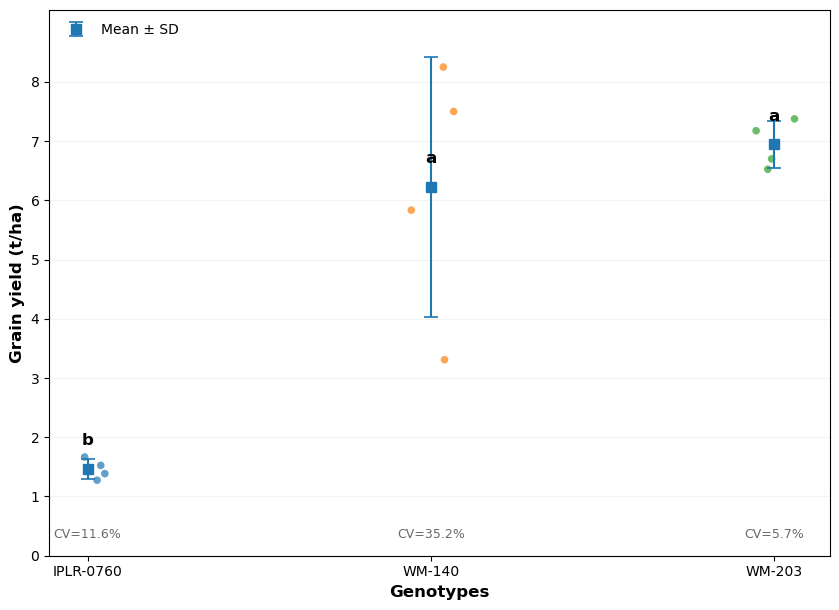

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------- DATA --------------------
data_dict = {
    'genotype': ['Galil', 'IPLR760', 'WM203', 'WM140',
                 'IPLR760', 'WM140', 'WM203', 'Galil',
                 'IPLR760', 'WM140', 'Galil', 'WM203',
                 'WM140', 'Galil', 'WM203', 'IPLR760'],
    'replicate': [5, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 8],
    'kg_per_m2': [0.4075, 0.1525, 0.7175, 0.583333,
                  0.166667, 0.75, 0.67, 0.473333,
                  0.1386, 0.825, 0.555833, 0.6525,
                  0.330833, 0.351667, 0.7375, 0.1275]
}

df = pd.DataFrame(data_dict)

# ---------------------- REMOVE GALIL ----------------------
df = df[df["genotype"] != "Galil"].copy()

df["replicate"] = df["replicate"] - 4
df["t_ha"] = df["kg_per_m2"] * 10

name_mapping = {'IPLR760': 'IPLR-0760', 'WM140': 'WM-140', 'WM203': 'WM-203'}
df["Genotype"] = df["genotype"].map(name_mapping)

# Order
genotype_order = ['IPLR-0760', 'WM-140', 'WM-203']

# Stats
summary = (df.groupby("Genotype")["t_ha"]
             .agg(['mean', 'std'])
             .reindex(genotype_order))
summary["cv"] = (summary["std"] / summary["mean"]) * 100

overall_mean = df["t_ha"].mean()

# Significance groups (update letters if needed after re-running stats without Galil)
sig_groups = {"IPLR-0760": "b", "WM-140": "a", "WM-203": "a"}

# -------------------- PLOT --------------------
fig, ax = plt.subplots(figsize=(8.5, 6.2))
x = np.arange(len(genotype_order))

# 1) raw points with gentle jitter
rng = np.random.default_rng(42)
for i, g in enumerate(genotype_order):
    yvals = df.loc[df["Genotype"] == g, "t_ha"].values
    jitter = rng.uniform(-0.07, 0.07, size=len(yvals))
    ax.scatter(np.full_like(yvals, i, dtype=float) + jitter, yvals,
               alpha=0.7, s=30, edgecolors='none')

# 2) means with SD error bars
ax.errorbar(x, summary["mean"].values, yerr=summary["std"].values,
            fmt='s', ms=7, lw=1.5, capsize=5, capthick=1.2, label="Mean ± SD")

# 3) overall mean reference
#ax.axhline(overall_mean, ls='--', lw=1.2, color='gray',
#           label=f"Overall mean = {overall_mean:.2f} t/ha")

# 4) significance letters above means
for i, g in enumerate(genotype_order):
    y = summary.loc[g, "mean"]
    ax.text(i, y + 0.35, sig_groups[g], ha='center', va='bottom',
            fontsize=12, fontweight='bold')

# Axes and labels
ax.set_xticks(x)
ax.set_xticklabels(genotype_order)
ax.set_xlabel("Genotypes", fontsize=12, fontweight="bold")
ax.set_ylabel("Grain yield (t/ha)", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(8.5, (summary["mean"] + summary["std"]).max() + 0.8))
ax.set_yticks(np.arange(0, 9, 1))

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.grid(axis='y', alpha=0.15)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="upper left")

# CV% annotations under x labels
for i, g in enumerate(genotype_order):
    ax.text(i, 0.25, f"CV={summary.loc[g, 'cv']:.1f}%",
            ha='center', va='bottom', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('figure2_no_galil.png', dpi=600, bbox_inches='tight')
plt.show()

Mean chlorophyll fluorescence.

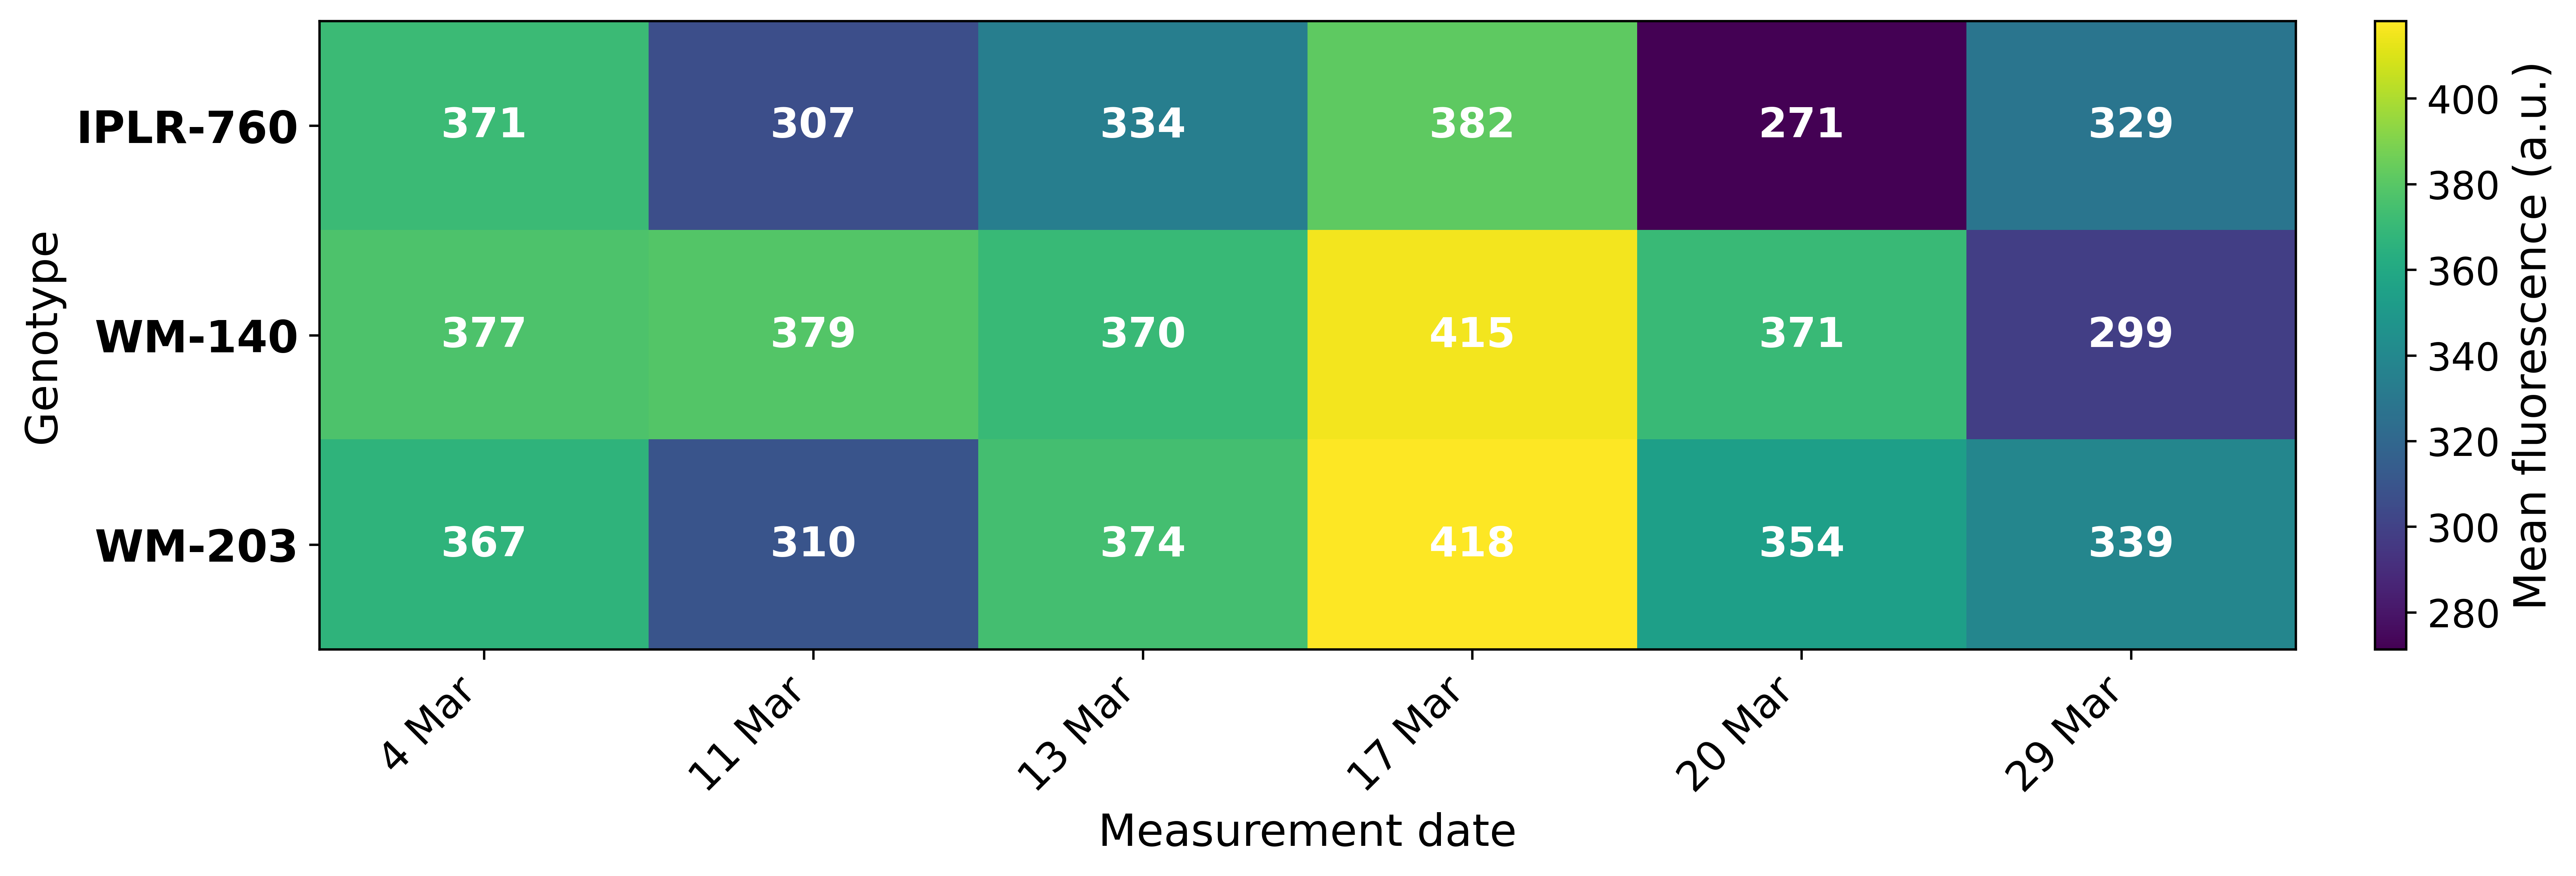

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------- DATA ----------------------
data_dict_fl = {
    "Genotype": ["Svevo"] * 5 + ["IL20"] * 5 + ["IPLR-760"] * 5 + ["WM-140"] * 5 + ["WM-203"] * 5 + ["Galil"] * 5,
    "20 Mar": [
        360.185913, 397.365631, 241.302399, 439.688995, 123.602219,
        174.413834, 411.534576, 304.831909, 150.205414, 416.031067,
        227.028275, 204.802994, 232.014511, 393.773041, 299.100555,
        323.307495, 351.922516, 411.148987, 352.282257, 416.356537,
        423.584106, 433.359283, 401.665985, 124.660774, 386.628998,
        451.207458, 413.72522, 364.320435, 397.695465, 392.825256
    ],
    "29 Mar": [
        249.439728, 201.849365, 199.906311, 232.767517, 174.858261,
        406.2742, 370.994446, 171.344589, 325.209839, 178.879837,
        237.709518, 360.796875, 332.126312, 351.903412, 360.635193,
        261.242828, 416.578644, 309.149231, 268.641327, 237.033524,
        402.212372, 398.15094, 212.016403, 278.930664, 401.744141,
        439.880341, 195.629929, 302.937164, 430.706543, 171.941544
    ],
    "4 Mar": [
        274.346039, 424.518036, 399.443024, 419.798462, 401.45047,
        413.124847, 402.91687, 369.381775, 399.077423, 391.666626,
        396.093079, 302.250031, 389.86377, 369.209137, 398.191071,
        435.129456, 388.750153, 356.983673, 385.514343, 320.561371,
        371.965393, 366.152496, 381.194061, 364.213074, 350.567291,
        395.937561, 423.394928, 455.72229, 425.287292, 399.537994
    ],
    "11 Mar": [
        378.462189, 328.23761, 288.38681, 405.0448, 445.262482,
        290.790863, 348.281616, 317.919861, 449.531555, 433.602142,
        252.123764, 303.901031, 323.571289, 413.233063, 239.74115,
        350.694763, 437.082916, 275.926636, 486.908997, 342.520569,
        283.683075, 253.648727, 344.567108, 227.993515, 437.67868,
        420.36261, 450.150696, 232.132721, 453.905182, 394.173645
    ],
    "13 Mar": [
        406.683228, 429.975769, 246.33403, 402.475311, 302.085602,
        417.820343, 246.299591, 251.870117, 405.348053, 404.592987,
        386.922028, 313.942841, 405.834076, 256.752563, 307.450256,
        361.757904, 397.710754, 391.133881, 368.990326, 331.626617,
        422.830475, 348.054077, 402.531342, 293.05661, 403.73288,
        378.44989, 232.896652, 353.823212, 173.427338, 250.286652
    ],
    "17 Mar": [
        431.730194, 440.514191, 396.583435, 431.343384, 411.72879,
        464.905151, 320.665497, 414.265808, 464.74234, 412.300232,
        394.195709, 346.250458, 346.897949, 367.314453, 453.491974,
        401.238342, 427.516541, 374.152832, 430.628235, 442.937469,
        431.910217, 357.205139, 432.070221, 460.786224, 408.507996,
        430.908356, 448.172485, 413.649292, 460.038635, 411.061646
    ]
}

df = pd.DataFrame(data_dict_fl)

# ---------------------- CLEAN AND FILTER ----------------------
seen = set()
keep_cols = ["Genotype"]
for c in df.columns:
    if c == "Genotype":
        continue
    if c not in seen:
        keep_cols.append(c)
        seen.add(c)
df = df[keep_cols]
df = df[~df["Genotype"].isin(["Svevo", "IL20", "Galil"])].copy()

# ---------------------- ORDER DATES ----------------------
date_cols = [c for c in df.columns if c != "Genotype"]

month_map = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
             "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}

def _parse_date_label(s):
    parts = s.split()
    day = int(parts[0])
    month = month_map[parts[1]]
    return (month, day)

date_cols = sorted(date_cols, key=_parse_date_label)

# ---------------------- LONG FORMAT ----------------------
long = df.melt(id_vars="Genotype", value_vars=date_cols,
               var_name="Date", value_name="FL")
long["FL"] = pd.to_numeric(long["FL"], errors="coerce")
long = long.dropna(subset=["FL"])

# ---------------------- SUMMARY ----------------------
summ = (long.groupby(["Date", "Genotype"])["FL"]
        .agg(["mean", "std", "count"])
        .reset_index())
summ["se"] = summ["std"] / np.sqrt(summ["count"])

gen_order = ["IPLR-760", "WM-140", "WM-203"]
gen_order = [g for g in gen_order if g in long["Genotype"].unique()]

mat    = (summ.pivot(index="Genotype", columns="Date", values="mean")
          .reindex(gen_order)[date_cols])
mat_sd = (summ.pivot(index="Genotype", columns="Date", values="std")
          .reindex(gen_order)[date_cols])
mat_se = (summ.pivot(index="Genotype", columns="Date", values="se")
          .reindex(gen_order)[date_cols])

# ---------------------- SHARED SETTINGS ----------------------
colors = {"IPLR-760": "#ff7f0e", "WM-140": "#2ca02c", "WM-203": "#1f77b4"}
x      = np.arange(len(date_cols))
width  = 0.25

# ============================================================
# OPTION 1 — Annotated heatmap (values inside cells)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4), dpi=600, constrained_layout=True)
im = ax.imshow(mat.values, aspect="auto", interpolation="nearest",
               cmap="viridis")
ax.set_yticks(np.arange(len(gen_order)))
ax.set_yticklabels(gen_order, fontsize=15, fontweight="bold")
ax.set_xticks(np.arange(len(date_cols)))
ax.set_xticklabels(date_cols, rotation=45, ha="right", fontsize=14)
ax.set_xlabel("Measurement date", fontsize=15)
ax.set_ylabel("Genotype", fontsize=15)
threshold = mat.values.mean()
for i, gen in enumerate(gen_order):
    for j, date in enumerate(date_cols):
        val = mat.loc[gen, date]
        txt_col = "white"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=14, fontweight="bold", color=txt_col)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean fluorescence (a.u.)", fontsize=15)
cbar.ax.tick_params(labelsize=13)
plt.savefig("FL_option1_annotated_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()


Mean Stomatal Conductance

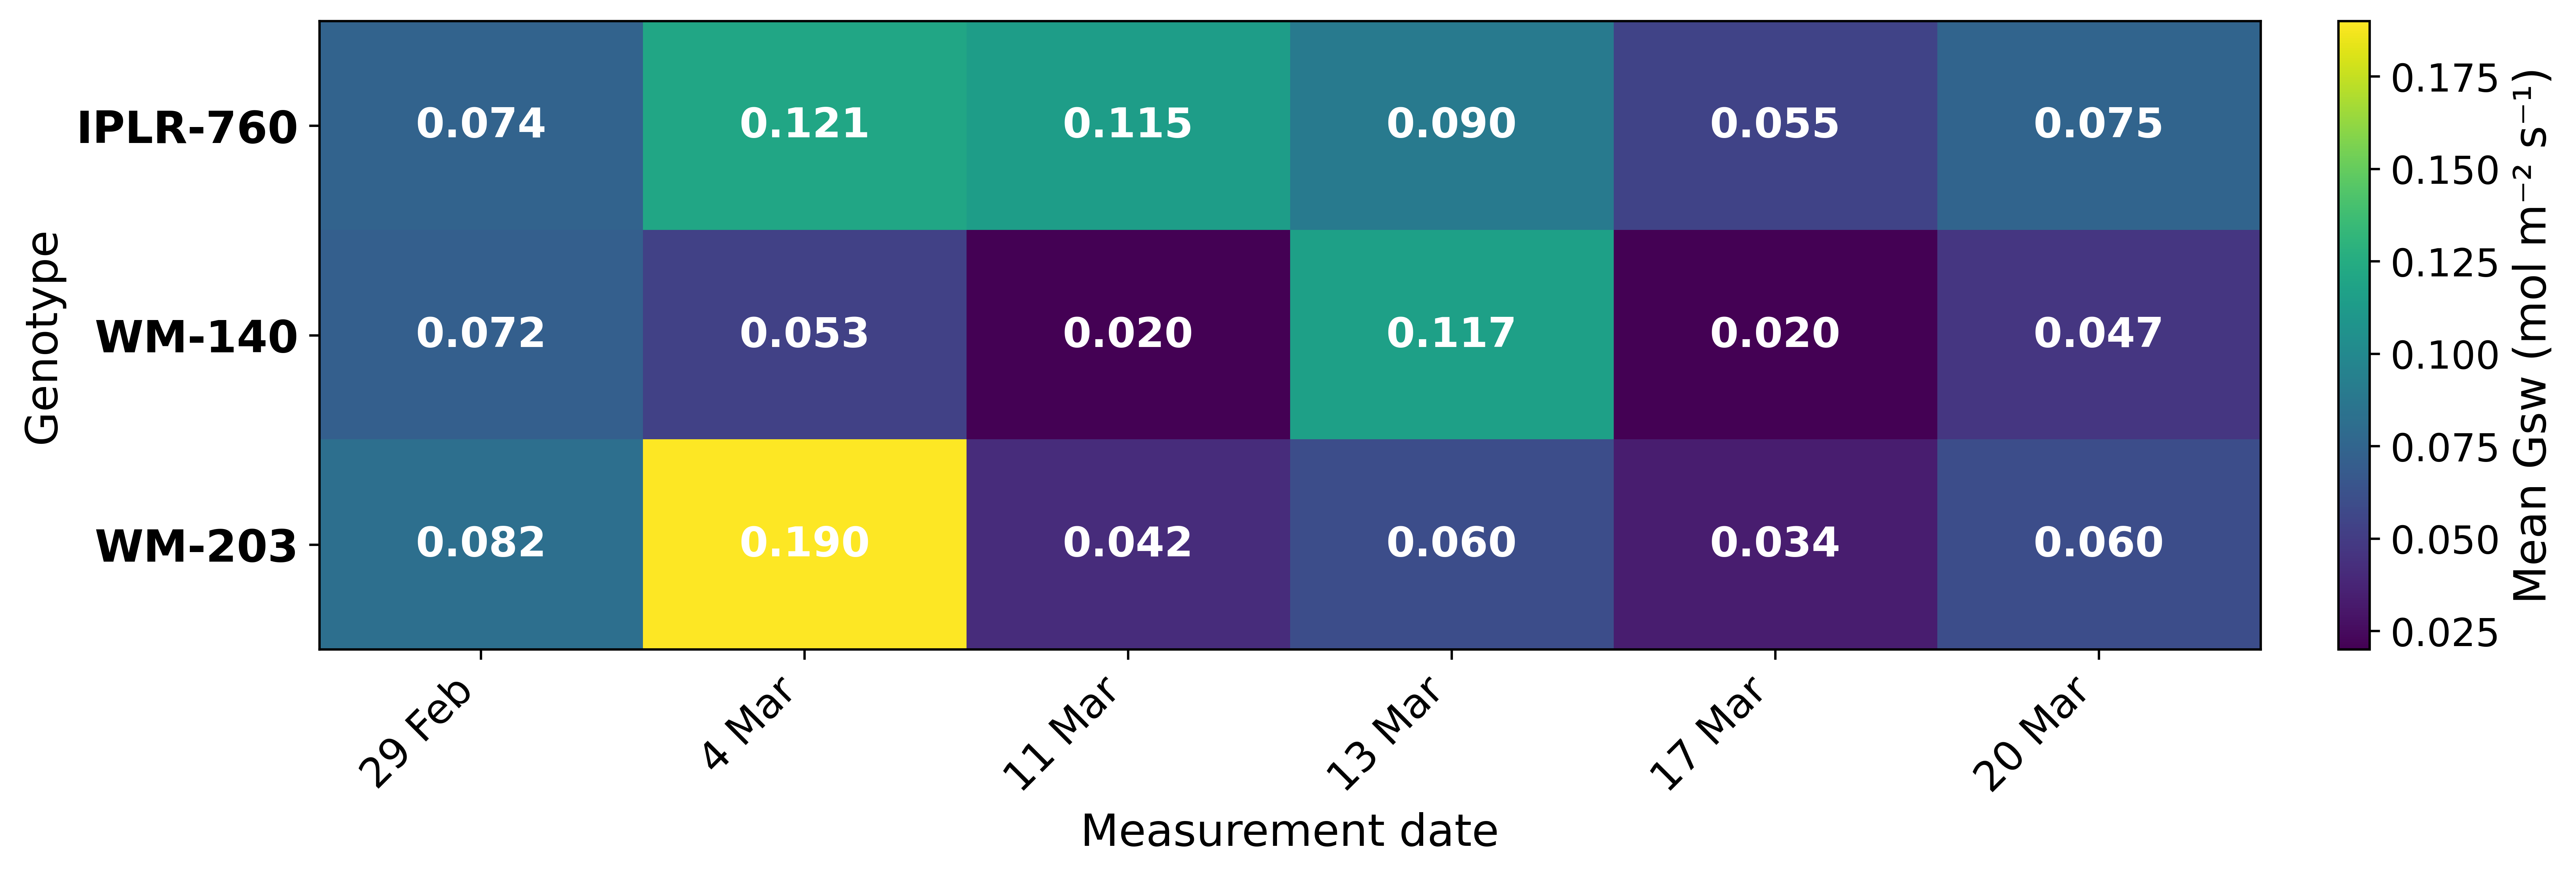

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- DATA --------------------
data_dict = {
    "Genotype": ["Svevo"] * 5 + ["IL20"] * 5 + ["IPLR-760"] * 5 + ["WM-140"] * 5 + ["WM-203"] * 5 + ["Galil"] * 5,
    "29 Feb": [
        0.005708863, 0.054146875, 0.17233125, 0.099842799, 0.137913714,
        0.083160243, 0.055561867, 0.136866039, 0.095324722, 0.151534109,
        0.103077022, 0.047175276, 0.030751453, 0.140495284, 0.049417728,
        0.080272573, 0.151385918, 0.041298099, 0.035577284, 0.04965312,
        0.056770952, 0.122683875, 0.0369752, 0.038883308, 0.156464857,
        0.198958639, 0.328872055, 0.092320934, 0.243288404, 0.365249768
    ],
    "4 Mar": [
        0.004266, 0.153824, 0.106671, 0.185488, 0.025726,
        0.066388, 0.062852, 0.018973, 0.212951, 0.084126,
        0.152608, 0.083159, 0.065081, 0.171651, 0.131504,
        0.050166, 0.095838, 0.025998, -0.004322, 0.09617,
        0.11094, 0.190293, 0.202102, 0.198319, 0.248285,
        0.056138, 0.134077, 0.2061, 0.126141, 0.167022
    ],
    "11 Mar": [
        0.03412848, 0.010079159, 0.004919814, 0.004957337, 0.033447491,
        -0.000270486, 0.007045304, 0.004929789, 0.01673606, 0.033452132,
        0.02277884, 0.234224306, 0.155618263, 0.096916243, 0.065248055,
        0.05201349, 0.017843244, 0.010523341, 0.015956824, 0.005746372,
        0.009227239, 0.017733088, 0.024742526, 0.044001809, 0.113705635,
        0.020058368, 0.097717023, 0.04703045, 0.012843178, 0.067303316
    ],
    "13 Mar": [
        0.035133, 0.078815, 0.009929, 0.001794, 0.005477,
        0.068235, 0.028969, 0.021355, 0.027149, 0.062754,
        0.090946, 0.099236, 0.106238, 0.032745, 0.118535,
        0.099046, 0.08814, 0.161455, 0.137821, 0.09686,
        0.154341, 0.010922, 0.019572, 0.016218, 0.101186,
        0.115979, 0.087959, 0.110062, 0.010687, 0.02552
    ],
    "17 Mar": [
        0.013948, 0.016972, 0.008701, 0.006595, 0.033821,
        0.007987, 0.008801, 0.046378, 0.007224, 0.006649,
        0.094748, 0.035435, 0.032436, 0.071979, 0.038101,
        0.009355, 0.00297, 0.00339, 0.011681, 0.072704,
        0.052087, 0.002782, 0.011565, 0.051317, 0.051866,
        0.016311, 0.054195, 0.037421, 0.001376, 0.016041
    ],
    "20 Mar": [
        0.112138, 0.115727, 0.01886, 0.081192, 0.017587,
        0.008581, 0.094551, 0.008195, 0.043875, 0.039609,
        0.088125, 0.098122, 0.033106, 0.012832, 0.142381,
        0.009032, 0.038398, 0.04185, 0.026617, 0.118301,
        0.111717, 0.014145, 0.032312, 0.028675, 0.113888,
        0.16736, 0.012758, 0.067193, 0.119183, 0.046599
    ]
}

df = pd.DataFrame(data_dict)

# ---------------------- CLEAN AND FILTER ----------------------
df = df[~df["Genotype"].isin(["Svevo", "IL20", "Galil"])].copy()


# ---------------------- ORDER DATES ----------------------
date_cols = [c for c in df.columns if c != "Genotype"]

month_map = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
             "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}

def _parse_date_label(s):
    parts = s.split()
    day = int(parts[0])
    month = month_map[parts[1]]
    return (month, day)

date_cols = sorted(date_cols, key=_parse_date_label)

# ---------------------- LONG FORMAT ----------------------
long = df.melt(id_vars="Genotype", value_vars=date_cols,
               var_name="Date", value_name="Gsw")
long["Gsw"] = pd.to_numeric(long["Gsw"], errors="coerce")
long = long.dropna(subset=["Gsw"])

# ---------------------- SUMMARY ----------------------
summ = (long.groupby(["Date", "Genotype"])["Gsw"]
        .agg(["mean", "std", "count"])
        .reset_index())
summ["se"] = summ["std"] / np.sqrt(summ["count"])

gen_order = ["IPLR-760", "WM-140", "WM-203"]
gen_order = [g for g in gen_order if g in long["Genotype"].unique()]

mat    = (summ.pivot(index="Genotype", columns="Date", values="mean")
          .reindex(gen_order)[date_cols])
mat_se = (summ.pivot(index="Genotype", columns="Date", values="se")
          .reindex(gen_order)[date_cols])

colors = {"IPLR-760": "#ff7f0e", "WM-140": "#2ca02c", "WM-203": "#1f77b4"}
x      = np.arange(len(date_cols))
width  = 0.25

# ============================================================
# Annotated heatmap (values inside cells)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4), dpi=600, constrained_layout=True)
im = ax.imshow(mat.values, aspect="auto", interpolation="nearest",
               cmap="viridis")
ax.set_yticks(np.arange(len(gen_order)))
ax.set_yticklabels(gen_order, fontsize=15, fontweight="bold")
ax.set_xticks(np.arange(len(date_cols)))
ax.set_xticklabels(date_cols, rotation=45, ha="right", fontsize=14)
ax.set_xlabel("Measurement date", fontsize=15)
ax.set_ylabel("Genotype", fontsize=15)

# threshold for text colour contrast
threshold = mat.values.mean()
for i, gen in enumerate(gen_order):
    for j, date in enumerate(date_cols):
        val = mat.loc[gen, date]
        txt_col = "white"
        ax.text(j, i, f"{val:.3f}",
                ha="center", va="center",
                fontsize=14, fontweight="bold",
                color=txt_col)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Mean Gsw (mol m⁻² s⁻¹)", fontsize=15)
cbar.ax.tick_params(labelsize=13)
plt.savefig("GSW_option_annotated_heatmap.png", dpi=600, bbox_inches="tight")
plt.show()

# Microclimate data

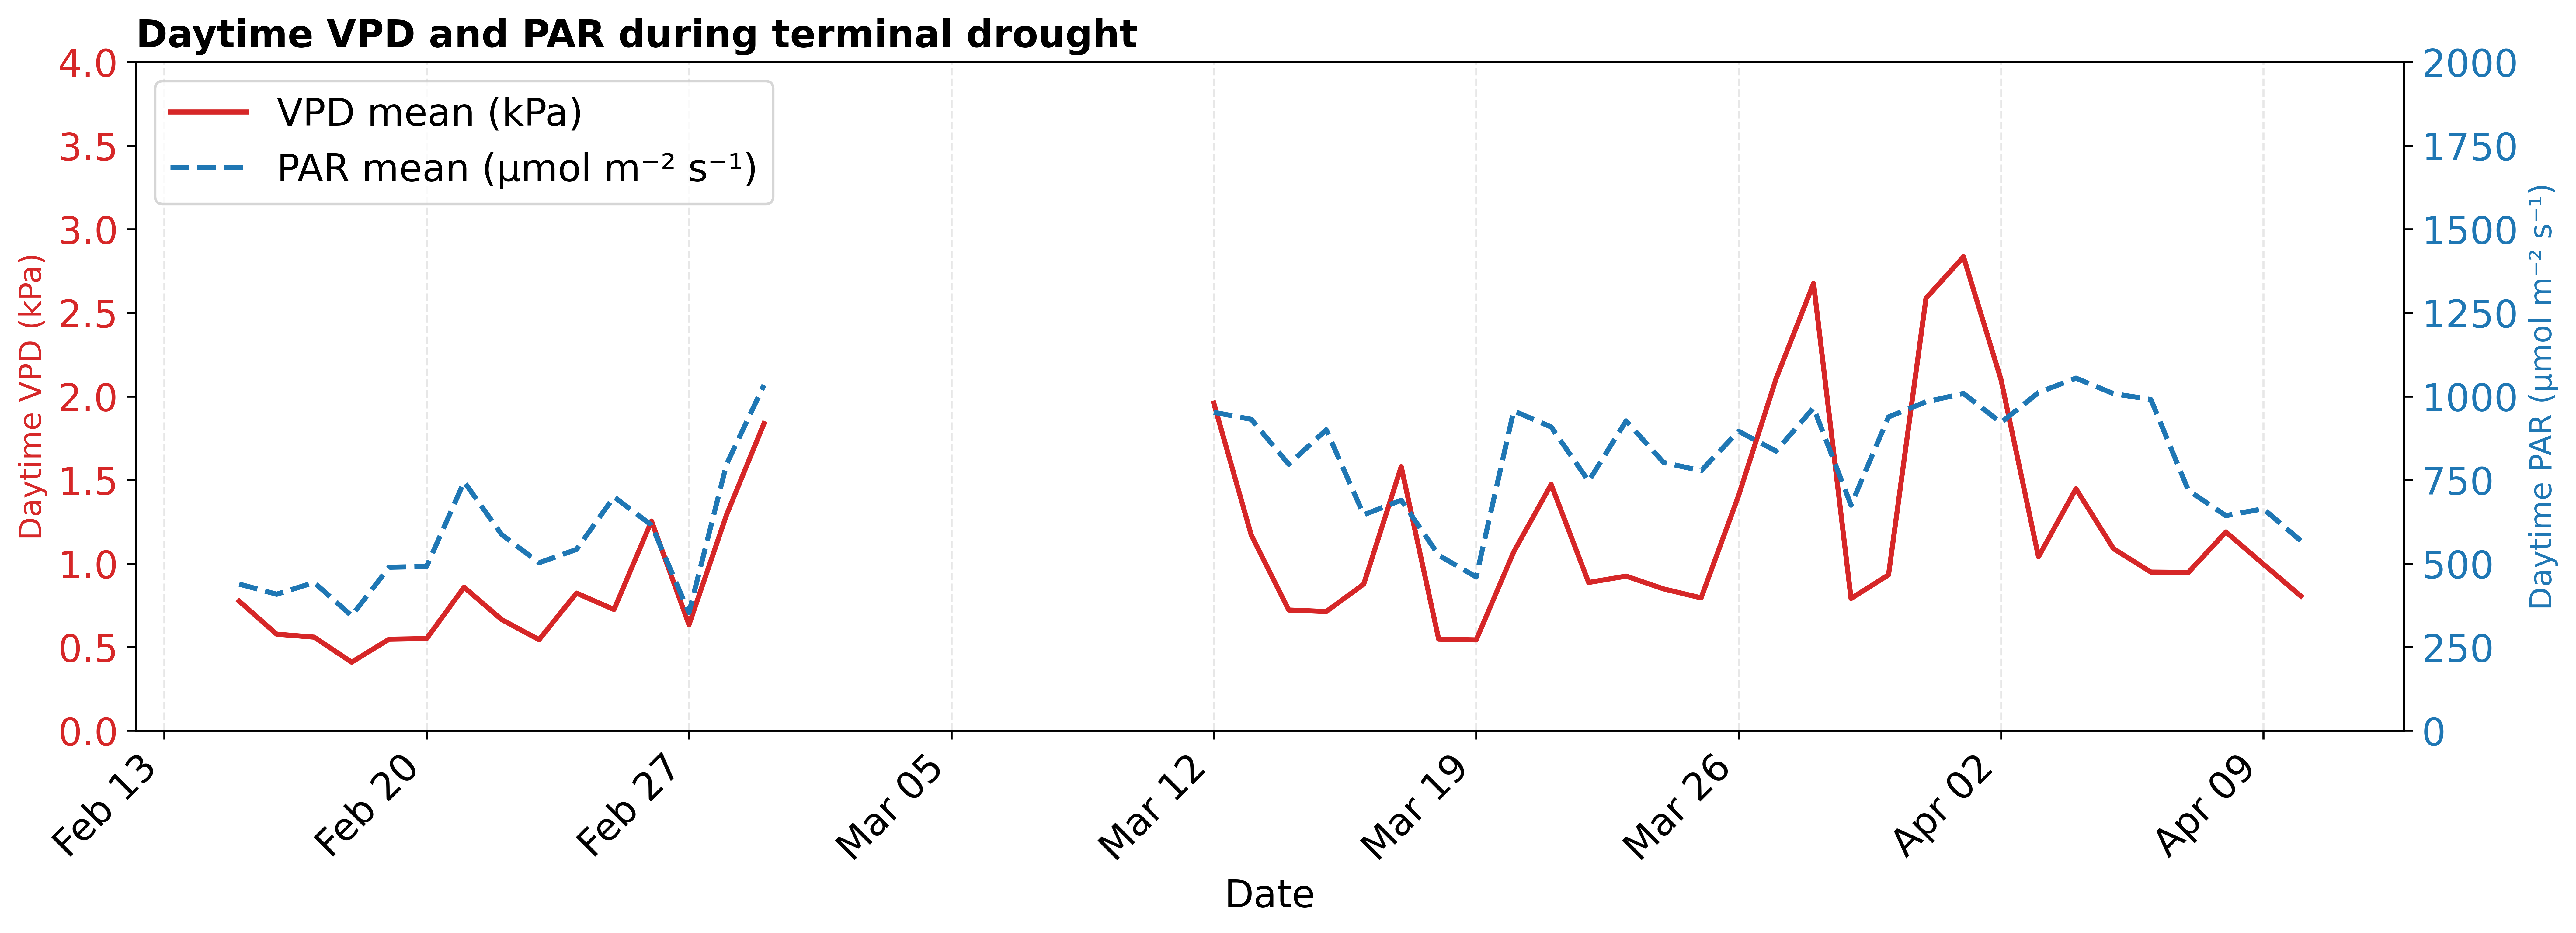

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------- LOAD DATA ----------------------
vpd = pd.read_csv("VPD.csv")
par = pd.read_csv("PAR.csv")

vpd.columns = vpd.columns.str.strip()
par.columns = ["Timestamp", "PAR"]

vpd["Timestamp"] = pd.to_datetime(vpd["Timestamp"], errors="coerce")
par["Timestamp"] = pd.to_datetime(par["Timestamp"], errors="coerce")
vpd["VPD (kPa)"] = pd.to_numeric(vpd["VPD (kPa)"], errors="coerce")
par["PAR"] = pd.to_numeric(par["PAR"], errors="coerce")

# ---------------------- MERGE ----------------------
df = vpd.merge(par, on="Timestamp")
df["Date"] = df["Timestamp"].dt.date

# ---------------------- DAILY DAYTIME SUMMARY ----------------------
daytime = df[df["PAR"] > 50].copy()
daytime["Date"] = daytime["Timestamp"].dt.date
daily = daytime.groupby("Date").agg(
    VPD_mean=("VPD (kPa)", "mean"),
    VPD_max=("VPD (kPa)",  "max"),
    PAR_mean=("PAR",        "mean"),
    PAR_max=("PAR",         "max"),
).reset_index()
daily["Date"] = pd.to_datetime(daily["Date"])
# Force daily timeline and keep gaps where data are missing
daily = daily.set_index("Date").asfreq("D").reset_index()

# ---------------------- MEASUREMENT DATES ----------------------
gsw_fl_dates = pd.to_datetime([
    "2024-02-29", "2024-03-05", "2024-03-12",
    "2024-03-13", "2024-03-17", "2024-03-20"
])
gsw_fl_labels = [
    "Feb 29\n(gsw 29.2)",
    "Mar 4*\n(gsw 4.3)",
    "Mar 11*\n(gsw 11.3)",
    "Mar 13\n(gsw 13.3)",
    "Mar 17\n(gsw 17.3)",
    "Mar 20\n(gsw 20.3)"
]
gsw_fl_labels_short = [
    "Feb 29", "Mar 4*", "Mar 11*",
    "Mar 13", "Mar 17", "Mar 20"
]

# ---------------------- BUILD MEASUREMENT DATE TABLE ----------------------
meas_data = []
for orig, proxy, lbl, lbl_short in zip(
    pd.to_datetime(["2024-02-18","2024-02-29","2024-03-04","2024-03-11",
                    "2024-03-13","2024-03-17","2024-03-20"]),
    gsw_fl_dates,
    gsw_fl_labels,
    gsw_fl_labels_short
):
    row = daily[daily["Date"] == proxy]
    if len(row) > 0:
        meas_data.append({
            "OrigDate":  orig,
            "ProxyDate": proxy,
            "Label":     lbl,
            "LabelShort":lbl_short,
            "VPD_mean":  row["VPD_mean"].values[0],
            "VPD_max":   row["VPD_max"].values[0],
            "PAR_mean":  row["PAR_mean"].values[0],
            "PAR_max":   row["PAR_max"].values[0],
        })

mdf = pd.DataFrame(meas_data)

# ============================================================
# Dual-axis time series (NO shading, NO extra vertical lines)
# ============================================================
drought_start = pd.Timestamp("2024-02-15")
drought_end   = pd.Timestamp("2024-04-10")
daily_drought = daily[(daily["Date"] >= drought_start) &
                      (daily["Date"] <= drought_end)]

fig, ax1 = plt.subplots(figsize=(14, 5), dpi=600, constrained_layout=True)

ax1.plot(
    daily_drought["Date"], daily_drought["VPD_mean"],
    color="#d62728", linewidth=2, label="VPD mean (kPa)", zorder=3
)
ax1.set_ylabel("Daytime VPD (kPa)", fontsize=12, color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728", labelsize=15)
ax1.set_ylim(0, 4)

ax2 = ax1.twinx()
ax2.plot(
    daily_drought["Date"], daily_drought["PAR_mean"],
    color="#1f77b4", linewidth=2, linestyle="--",
    label="PAR mean (µmol m⁻² s⁻¹)", zorder=3
)
ax2.set_ylabel("Daytime PAR (µmol m⁻² s⁻¹)", fontsize=12, color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4", labelsize=15)
ax2.set_ylim(0, 2000)

ax1.set_xlabel("Date", fontsize=15)
ax1.set_title(
    "Daytime VPD and PAR during terminal drought",
    fontsize=15, fontweight="bold", loc="left"
)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=15)

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2,
           fontsize=15, loc="upper left", framealpha=0.8)
ax1.grid(axis="x", linestyle="--", alpha=0.3)

plt.savefig("ENV_fig1_VPD_PAR_timeseries_clean.png", dpi=600, bbox_inches="tight")
plt.show()